In [1]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib
import time
import threading

In [2]:
path = "C:\\Program Files\\MetaTrader 5\\terminal64.exe"
login = 5030595537
password = "-r7lRdVn"
server = "MetaQuotes-Demo"
timeout = 10000
portable = False
if mt5.initialize(path=path, login=login, password=password, server=server, timeout=timeout, portable=portable):
    print("Initialization successful")
else:
    print("Initialization not successful")

Initialization successful


In [3]:
symbol = "EURUSD"

timeframe = mt5.TIMEFRAME_H1
from datetime import datetime

import pytz

end_time = datetime.today().astimezone(pytz.utc)

eurusd_rates = mt5.copy_rates_from(symbol, timeframe, end_time, 10000)

In [7]:
data = pd.DataFrame(eurusd_rates)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         10000 non-null  int64  
 1   open         10000 non-null  float64
 2   high         10000 non-null  float64
 3   low          10000 non-null  float64
 4   close        10000 non-null  float64
 5   tick_volume  10000 non-null  uint64 
 6   spread       10000 non-null  int32  
 7   real_volume  10000 non-null  uint64 
dtypes: float64(4), int32(1), int64(1), uint64(2)
memory usage: 586.1 KB


In [ ]:
data.to_csv('EURUSD_10000.csv', index=False)

In [8]:
data['time'] = pd.to_datetime(data['time'], unit='s').dt.tz_localize('UTC')

In [10]:
data.tail()

,time,open,high,low,close,tick_volume,spread,real_volume
9995,2024-12-10 04:00:00+00:00,1.05529,1.05613,1.05515,1.05532,1673,4,0
9996,2024-12-10 05:00:00+00:00,1.05532,1.05576,1.05489,1.05564,1472,4,0
9997,2024-12-10 06:00:00+00:00,1.05564,1.05598,1.05560,1.05574,1129,4,0
9998,2024-12-10 07:00:00+00:00,1.05576,1.05625,1.05540,1.05619,1195,4,0
9999,2024-12-10 08:00:00+00:00,1.05618,1.05680,1.05608,1.05665,1354,4,0


In [6]:

rates = mt5.copy_rates_from(symbol, timeframe, 1000)
print(rates)
da = pd.DataFrame(rates)

None


In [15]:
da.head()

""


In [2]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib
import time
import threading
from datetime import datetime
import pytz

class SVMTradingBot:
    def __init__(self, account, password, server, model_path, symbol="EURUSD", timeframe=mt5.TIMEFRAME_H1):
        print("Initializing SVMTradingBot...")
        self.account = account
        self.password = password
        self.server = server
        self.model_path = model_path
        self.symbol = symbol
        self.timeframe = timeframe
        self.scaler = StandardScaler()
        self.model = joblib.load(model_path)
        self.running = False
        
        # Initialize and connect to MetaTrader 5
        print("Connecting to MetaTrader 5...")
        if not mt5.initialize():
            print("initialize() failed, error code =", mt5.last_error())
            quit()

        authorized = mt5.login(self.account, password=self.password, server=self.server)
        if not authorized:
            print("Failed to connect to account. Error:", mt5.last_error())
            quit()
        print("Connected to MetaTrader 5")

    def fetch_data(self):
        print("Fetching data...")
        end_time = datetime.today().astimezone(pytz.utc)
        rates = mt5.copy_rates_from(self.symbol, self.timeframe, end_time, 10000)
        
        # Check if rates data is fetched successfully
        if rates is None:
            print("Failed to fetch data. Error:", mt5.last_error())
            return pd.DataFrame()  # Return an empty DataFrame to avoid further errors

        data = pd.DataFrame(rates)
        print("Data fetched successfully. DataFrame shape:", data.shape)
        print(data.head())  # Print the first few rows of the DataFrame to check its structure
        
        data['time'] = pd.to_datetime(data['time'], unit='s')
        data.set_index('time', inplace=True)
        return data

    def calculate_features(self, data):
        print("Calculating features...")
        data['Returns'] = data['close'].pct_change()
        data['SMA_5'] = data['close'].rolling(window=5).mean()
        data['SMA_10'] = data['close'].rolling(window=10).mean()
        data['SMA_20'] = data['close'].rolling(window=20).mean()
        data['EMA_5'] = data['close'].ewm(span=5, adjust=False).mean()
        data['EMA_10'] = data['close'].ewm(span=10, adjust=False).mean()
        data['Momentum'] = data['close'] - data['close'].shift(5)
        data['Volatility'] = data['Returns'].rolling(window=5).std()
        data['ROC_5'] = data['close'].pct_change(periods=5)
        data['Price_Change'] = data['close'].pct_change()
        data['Lag_1'] = data['close'].shift(1)
        data['RSI'] = 100 - (100 / (1 + data['Returns'].rolling(window=14).mean() /
                                     abs(data['Returns'].rolling(window=14).mean())))
        data.replace([np.inf, -np.inf], np.nan, inplace=True)
        data.dropna(inplace=True)
        print("Features calculated successfully")
        return data

    def make_predictions(self, data):
        print("Making predictions...")
        X = data[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'Momentum', 'Volatility', 'ROC_5', 'Price_Change', 'Lag_1', 'RSI']]
        X_scaled = self.scaler.fit_transform(X)
        y_pred = self.model.predict(X_scaled)
        data['Predicted_Signal'] = y_pred
        print("Predictions made successfully")
        return data

    def place_order(self, order_type, volume, price, stop_loss, take_profit):
        request = {
            "action": mt5.TRADE_ACTION_DEAL,
            "symbol": self.symbol,
            "volume": volume,
            "type": order_type,
            "price": price,
            "sl": stop_loss,
            "tp": take_profit,
            "deviation": 10,
            "magic": 234000,
            "comment": "SVMTradingBot order",
            "type_time": mt5.ORDER_TIME_GTC,
            "type_filling": mt5.ORDER_FILLING_IOC,
        }
        result = mt5.order_send(request)
        return result

    def close_order(self, ticket):
        position = mt5.positions_get(ticket=ticket)
        if not position:
            print(f"Position with ticket {ticket} not found")
            return None

        order_type = mt5.ORDER_TYPE_SELL if position[0].type == mt5.ORDER_TYPE_BUY else mt5.ORDER_TYPE_BUY
        price = mt5.symbol_info_tick(self.symbol).bid if order_type == mt5.ORDER_TYPE_BUY else mt5.symbol_info_tick(self.symbol).ask

        request = {
            "action": mt5.TRADE_ACTION_DEAL,
            "symbol": self.symbol,
            "volume": position[0].volume,
            "type": order_type,
            "price": price,
            "deviation": 10,
            "magic": 234000,
            "comment": "SVMTradingBot close",
            "type_time": mt5.ORDER_TIME_GTC,
            "type_filling": mt5.ORDER_FILLING_IOC,
            "position": ticket
        }

        result = mt5.order_send(request)
        if result.retcode != mt5.TRADE_RETCODE_DONE:
            print(f"Close order failed, retcode={result.retcode}")
            result_dict = result._asdict()
            for field in result_dict.keys():
                print("   {}={}".format(field, result_dict[field]))
        else:
            print(f"Order closed successfully, order ID: {result.order}")

        return result

    def execute_trade(self, prediction):
        print("Executing trade...")
        lot = 0.1
        current_positions = mt5.positions_get(symbol=self.symbol)
        current_position_type = current_positions[0].type if current_positions else None

        if prediction == 1:
            price = mt5.symbol_info_tick(self.symbol).ask
            stop_loss = price - 0.01
            take_profit = price + 0.01
            if not current_positions or current_position_type == mt5.ORDER_TYPE_SELL:
                if current_position_type == mt5.ORDER_TYPE_SELL:
                    self.close_order(current_positions[0].ticket)
                result = self.place_order(mt5.ORDER_TYPE_BUY, lot, price, stop_loss, take_profit)
                print("Buy order result:", result)
        elif prediction == 0:
            price = mt5.symbol_info_tick(self.symbol).bid
            stop_loss = price + 0.01
            take_profit = price - 0.01
            if not current_positions or current_position_type == mt5.ORDER_TYPE_BUY:
                if current_position_type == mt5.ORDER_TYPE_BUY:
                    self.close_order(current_positions[0].ticket)
                result = self.place_order(mt5.ORDER_TYPE_SELL, lot, price, stop_loss, take_profit)
                print("Sell order result:", result)
        print("Trade executed")

    def trade(self):
        print("Starting trading loop...")
        self.running = True
        while self.running:
            print("Trading iteration started")
            data = self.fetch_data()
            if data.empty:
                print("No data fetched, skipping this iteration.")
                time.sleep(30)
                continue
            data = self.calculate_features(data)
            data = self.make_predictions(data)
            latest_prediction = data['Predicted_Signal'].iloc[-1]
            print("Latest prediction:", latest_prediction)
            self.execute_trade(latest_prediction)
            print("Sleeping for 1 hour")
            time.sleep(30)  # Sleep for 1 hour (adjust as needed)
            print("Woke up, starting next iteration")

    def start(self):
        print("Starting bot...")
        self.thread = threading.Thread(target=self.trade)
        self.thread.start()

    def stop(self):
        print("Stopping bot...")
        self.running = False
        self.thread.join()
        print("Bot stopped")

# Example usage:
if __name__ == "__main__":
    bot = SVMTradingBot(
        account=5030595537,
        password="-r7lRdVn",
        server="MetaQuotes-Demo",
        model_path="../models/svm_model.pkl"
    )
    bot.start()

    # Run for a certain period or based on a condition
    time.sleep(300)  # Run for 5 minutes
    bot.stop()


Initializing SVMTradingBot...
Connecting to MetaTrader 5...
Connected to MetaTrader 5
Starting bot...
Starting trading loop...
Trading iteration started
Fetching data...
Data fetched successfully. DataFrame shape: (10000, 8)
         time     open     high      low    close  tick_volume  spread  \
0  1683082800  1.10108  1.10206  1.10049  1.10173         1254       0   
1  1683086400  1.10174  1.10242  1.10129  1.10228         1523       0   
2  1683090000  1.10228  1.10258  1.10197  1.10253         1189       0   
3  1683093600  1.10253  1.10299  1.10251  1.10295          805       0   
4  1683097200  1.10295  1.10296  1.10214  1.10218         1156       0   

   real_volume  
0            0  
1            0  
2            0  
3            0  
4            0  
Calculating features...
Features calculated successfully
Making predictions...
Predictions made successfully
Latest prediction: 1.05711
Executing trade...
Trade executed
Sleeping for 1 hour
Woke up, starting next iteration
Tradi

In [63]:
# import MetaTrader5 as mt5
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report
# import joblib
# from datetime import datetime, timedelta
# import pytz

# # Initialize and connect to MetaTrader 5
# if not mt5.initialize():
#     print("initialize() failed, error code =", mt5.last_error())
#     quit()

# account = 5030595537
# password = "-r7lRdVn"
# server = "MetaQuotes-Demo"

# authorized = mt5.login(account, password=password, server=server)
# if not authorized:
#     print("Failed to connect to account. Error:", mt5.last_error())
#     quit()

# print("Connected to MetaTrader 5")

# # Parameters
# symbol = "EURUSD"
# timeframe = mt5.TIMEFRAME_M1
# model_path = "../models/svm_model.pkl"
# day_to_backtest = "2023-12-01"  # Change this to the specific day you want to backtest

# # Load the SVM model
# model = joblib.load(model_path)

# # Define the date range
# start_date = datetime.strptime(day_to_backtest, "%Y-%m-%d")
# end_date = start_date + timedelta(days=1)

# # Convert to UTC
# start_date = start_date.astimezone(pytz.utc)
# end_date = end_date.astimezone(pytz.utc)

# # Fetch data
# print("Fetching data...")
# rates = mt5.copy_rates_range(symbol, timeframe, start_date, end_date)
# if rates is None:
#     print("Failed to fetch data. Error:", mt5.last_error())
#     quit()

# data = pd.DataFrame(rates)
# data['time'] = pd.to_datetime(data['time'], unit='s')
# data.set_index('time', inplace=True)

# # Feature calculation
# def calculate_features(data):
#     data['Returns'] = data['close'].pct_change()
#     data['SMA_5'] = data['close'].rolling(window=5).mean()
#     data['SMA_10'] = data['close'].rolling(window=10).mean()
#     data['SMA_20'] = data['close'].rolling(window=20).mean()
#     data['EMA_5'] = data['close'].ewm(span=5, adjust=False).mean()
#     data['EMA_10'] = data['close'].ewm(span=10, adjust=False).mean()
#     data['Momentum'] = data['close'] - data['close'].shift(5)
#     data['Volatility'] = data['Returns'].rolling(window=5).std()
#     data['ROC_5'] = data['close'].pct_change(periods=5)
#     data['Price_Change'] = data['close'].pct_change()
#     data['Lag_1'] = data['close'].shift(1)
#     data['RSI'] = 100 - (100 / (1 + data['Returns'].rolling(window=14).mean() / abs(data['Returns'].rolling(window=14).mean())))
#     data.replace([np.inf, -np.inf], np.nan, inplace=True)
#     data.dropna(inplace=True)
#     return data

# data = calculate_features(data)

# # Prepare the data for prediction
# X = data[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'Momentum', 'Volatility', 'ROC_5', 'Price_Change', 'Lag_1', 'RSI']]

# # Fit and transform the scaler
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Make predictions
# data['Predicted_Signal'] = model.predict(X_scaled)

# # Assuming you have actual signals to compare, you can replace the following with your actual signals
# # For demonstration, let's create a random actual signal
# np.random.seed(42)
# data['Actual_Signal'] = np.random.choice([0, 1], size=len(data))

# # Evaluate the model's performance
# print("Model Performance:")
# print(classification_report(data['Actual_Signal'], data['Predicted_Signal']))

# # Disconnect from MetaTrader 5
# mt5.shutdown()


,return,pred,label,won,pnl,equity,time
28412,0.00008,0,1.0,False,-0.008,2.870,2024-12-04 05:17:00
28413,-0.00012,0,0.0,True,0.012,2.882,2024-12-04 05:18:00
28414,-0.00003,1,0.0,False,-0.003,2.879,2024-12-04 05:19:00
28415,0.00001,0,1.0,False,-0.001,2.878,2024-12-04 05:20:00
28416,-0.00006,0,0.0,True,0.006,2.884,2024-12-04 05:21:00


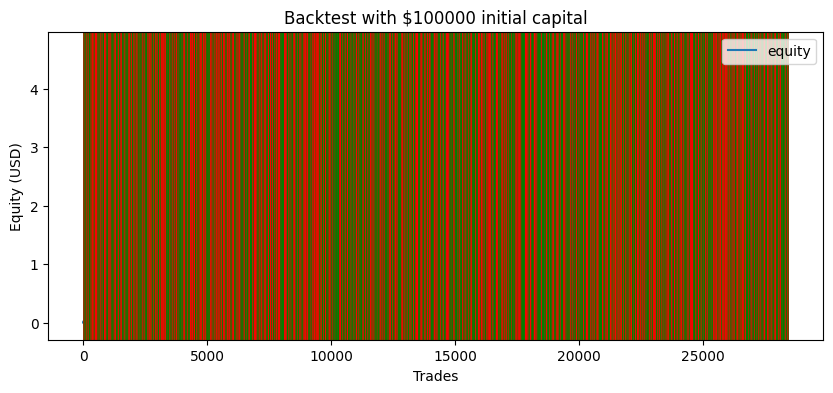

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import load

# Load the model from the file
loaded_model = load('nexo_xgb.joblib')

# Load the new testing dataset
new_test_data = pd.read_csv('../datasets/EURUSD_M1_LARGE_data.csv')

# Preprocess the new test data to match the training data preprocessing steps

# Normalize 'Adj Close' value
new_test_data['Adj Close'] = new_test_data['close']
new_test_data['return'] = new_test_data['Adj Close'] - new_test_data['Adj Close'].shift(1)
return_range = new_test_data['return'].max() - new_test_data['return'].min()
new_test_data['return'] = new_test_data['return'] / return_range

# Make label (1 as rising price, 0 as falling price)
new_test_data['label'] = new_test_data['return'].shift(-1)
new_test_data['label'] = new_test_data['label'].apply(lambda x: 1 if x > 0.0 else 0)
new_test_data.dropna(inplace=True)

# Extract features and labels for the test set
n_features = 60  # number of features

test_x = np.array([]).reshape([-1, n_features])
test_y = np.array([]).reshape([-1, 1])
trade_times =[]

for index, row in new_test_data.iterrows():
    i = new_test_data.index.get_loc(index)
    if i < n_features:
        continue

    _x = np.array(new_test_data[i - n_features + 1:i + 1]['return']).T.reshape([1, -1])
    _y = new_test_data.iloc[i]['label']
    test_x = np.vstack((test_x, _x))
    test_y = np.vstack((test_y, _y))
    
    # Store the corresponding time for the trade
    trade_times.append(new_test_data.iloc[i]['time'])

test_y = test_y.reshape([-1])

# Make predictions with the loaded model
predictions = loaded_model.predict(test_x)

# Parameters
trade_amount = 100.0
commission = 0.0
stop_loss = 0.02  # Example stop-loss at 2%
take_profit = 0.05  # Example take-profit at 5%

# DataFrame to store trade data
df_trade = pd.DataFrame(test_x[:, -1], columns=['return'])
df_trade['pred'] = predictions
df_trade['label'] = test_y
df_trade['won'] = df_trade['label'] == df_trade['pred']
df_trade['return'] = df_trade['return'].shift(-1) * return_range
df_trade.drop(df_trade.index[len(df_trade) - 1], inplace=True)

def calc_profit(row):
    trade_return = row['return']
    
    # Apply stop-loss
    if trade_return <= -stop_loss:
        pnl = -stop_loss * trade_amount - commission
    # Apply take-profit
    elif trade_return >= take_profit:
        pnl = take_profit * trade_amount - commission
    else:
        # Regular calculation
        if row['won']:
            pnl = abs(trade_return) * trade_amount - commission
        else:
            pnl = -abs(trade_return) * trade_amount - commission
    
    return pnl

# Calculate profit and equity
df_trade['pnl'] = df_trade.apply(lambda row: calc_profit(row), axis=1)
df_trade['equity'] = df_trade['pnl'].cumsum()
# Ensure the lengths of trade_times and df_trade match
trade_times = trade_times[:len(df_trade)]  # Trim trade_times if it has extra elements
df_trade['time'] = trade_times  # Add the time of trade execution

# Display the last few rows of the DataFrame
display(df_trade.tail())

# Plot equity curve
df_trade.plot(y='equity', figsize=(10, 4), title='Backtest with $100000 initial capital')
plt.xlabel('Trades')
plt.ylabel('Equity (USD)')

# Highlight trades on the plot
for r in df_trade.iterrows():
    if r[1]['won']:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='g')
    else:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='r')

plt.show()


Net Profit            : $2.88
Total win volume      : 148
Total loss volume     : -145
Number Winning Trades : 13264
Number Losing Trades  : 13270
Percent Profitable    : 49.99%
Avg Win Trade         : $0.011
Avg Los Trade         : $-0.011
Largest Win Trade     : $0.385
Largest Los Trade     : $-0.619
Profit Factor         : 1.02


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9320\2939523137.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])


<Axes: >

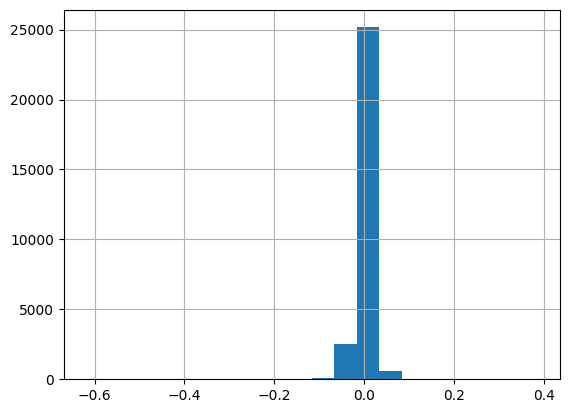

In [46]:
# Calculate summary of trades
n_win_trades = float(df_trade[df_trade['pnl']>0.0]['pnl'].count())
n_los_trades = float(df_trade[df_trade['pnl']<0.0]['pnl'].count())
win_vol = df_trade[df_trade['pnl']>0.0]['pnl'].mean() * n_win_trades
loss_vol = df_trade[df_trade['pnl']<0.0]['pnl'].mean() * n_los_trades
# risk_exposure = df_trade['risk'].sum()
print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])
# print("Risk Exposure         : %d" % risk_exposure)
print("Total win volume      : %d" % win_vol)
print("Total loss volume     : %d" % loss_vol)
print("Number Winning Trades : %d" % n_win_trades)
print("Number Losing Trades  : %d" % n_los_trades)
print("Percent Profitable    : %.2f%%" % (100*n_win_trades/(n_win_trades + n_los_trades)))
print("Avg Win Trade         : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].mean())
print("Avg Los Trade         : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].mean())
print("Largest Win Trade     : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].max())
print("Largest Los Trade     : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].min())
print("Profit Factor         : %.2f" % abs(df_trade[df_trade['pnl']>0.0]['pnl'].sum()/df_trade[df_trade['pnl']<0.0]['pnl'].sum()))

df_trade['pnl'].hist(bins=20)

In [25]:
df_trade.head()

,return,pred,label,won,pnl,equity
0,0.00000,0,0.0,True,0.000,0.000
1,-0.00011,0,0.0,True,0.011,0.011
2,0.00006,1,1.0,True,0.006,0.017
3,-0.00001,0,0.0,True,0.001,0.018
4,0.00001,0,1.0,False,-0.001,0.017


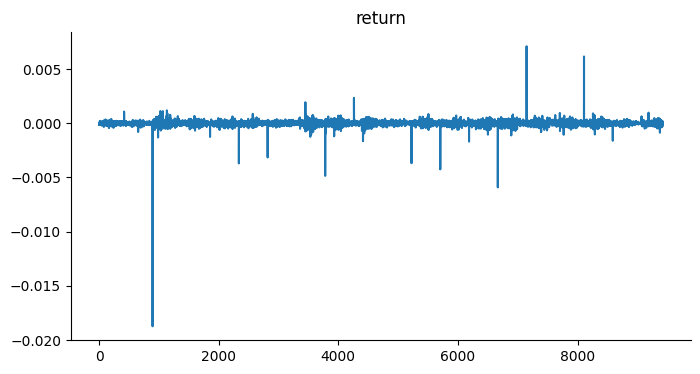

In [37]:
# @title return

from matplotlib import pyplot as plt
df_trade['return'].plot(kind='line', figsize=(8, 4), title='return')
plt.gca().spines[['top', 'right']].set_visible(False)

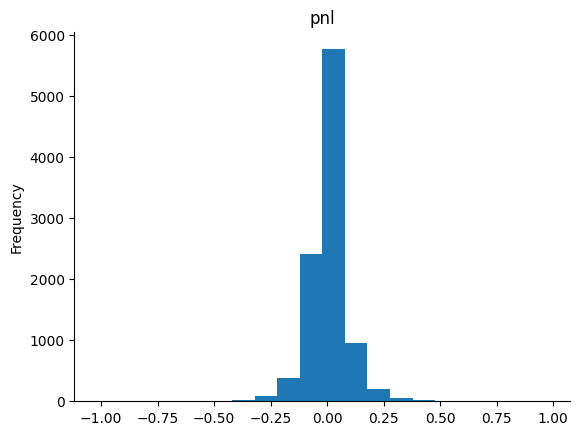

In [16]:
# @title pnl

from matplotlib import pyplot as plt
df_trade['pnl'].plot(kind='hist', bins=20, title='pnl')
plt.gca().spines[['top', 'right',]].set_visible(False)

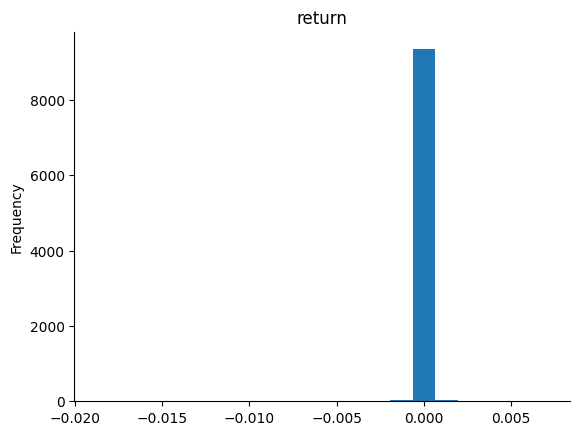

In [36]:
# @title return

from matplotlib import pyplot as plt
df_trade['return'].plot(kind='hist', bins=20, title='return')
plt.gca().spines[['top', 'right',]].set_visible(False)

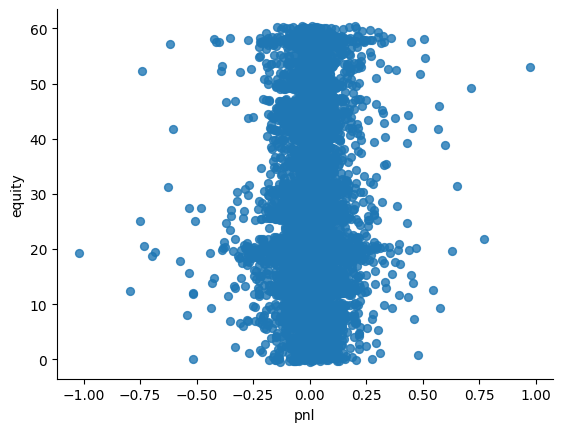

In [18]:
# @title pnl vs equity

from matplotlib import pyplot as plt
df_trade.plot(kind='scatter', x='pnl', y='equity', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

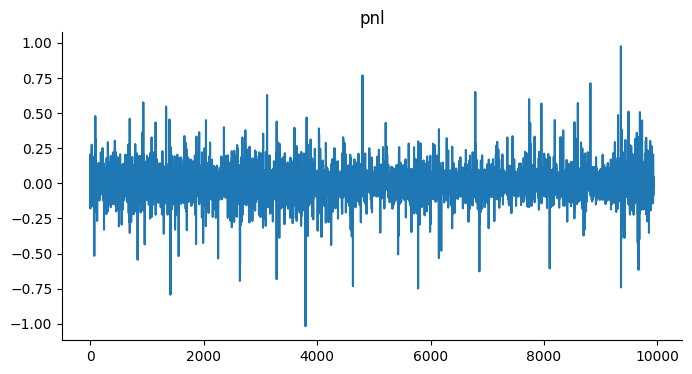

In [19]:
# @title pnl

from matplotlib import pyplot as plt
df_trade['pnl'].plot(kind='line', figsize=(8, 4), title='pnl')
plt.gca().spines[['top', 'right']].set_visible(False)

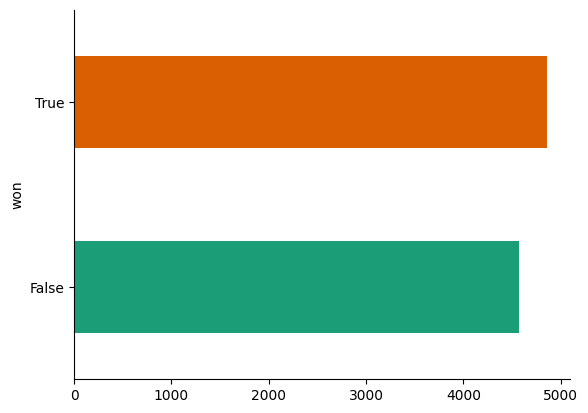

In [35]:
# @title won

from matplotlib import pyplot as plt
import seaborn as sns
df_trade.groupby('won').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

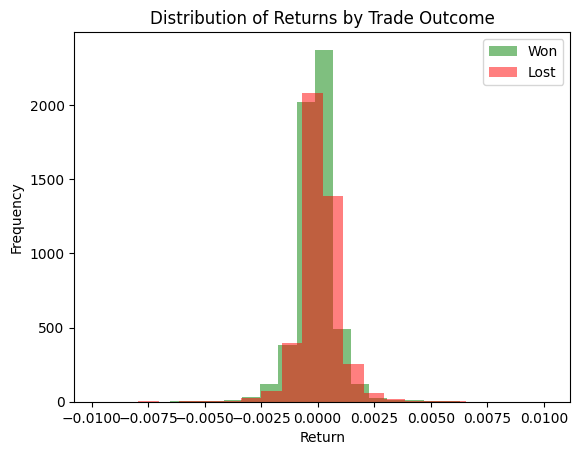

In [21]:
# @title Distribution of Returns by Trade Outcome

import matplotlib.pyplot as plt

plt.hist(df_trade[df_trade['won'] == True]['return'], bins=20, alpha=0.5, label='Won', color='green')
plt.hist(df_trade[df_trade['won'] == False]['return'], bins=20, alpha=0.5, label='Lost', color='red')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.title('Distribution of Returns by Trade Outcome')
_ = plt.legend()

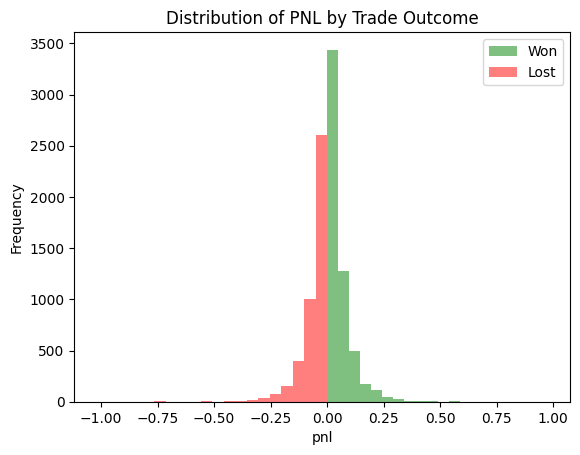

In [22]:
# @title Distribution of Returns by Trade Outcome

import matplotlib.pyplot as plt

plt.hist(df_trade[df_trade['won'] == True]['pnl'], bins=20, alpha=0.5, label='Won', color='green')
plt.hist(df_trade[df_trade['won'] == False]['pnl'], bins=20, alpha=0.5, label='Lost', color='red')
plt.xlabel('pnl')
plt.ylabel('Frequency')
plt.title('Distribution of PNL by Trade Outcome')
_ = plt.legend()

In [26]:
df = pd.read_csv('../datasets/EURUSD_M1_LARGE_data.csv')
df.head()

,time,open,high,low,close,tick_volume
0,2024-11-04 05:23:00,1.08997,1.09002,1.08995,1.09002,29
1,2024-11-04 05:24:00,1.09004,1.09008,1.09000,1.09000,28
2,2024-11-04 05:25:00,1.09001,1.09004,1.08995,1.08995,25
3,2024-11-04 05:26:00,1.08995,1.08995,1.08990,1.08990,15
4,2024-11-04 05:27:00,1.08991,1.08995,1.08987,1.08995,16


,return,pred,label,won,time,pnl,equity
9419,0.00009,0,1.0,False,2024-11-29 18:48:00,-0.009,2.438
9420,-0.00028,0,0.0,True,2024-11-29 18:49:00,0.028,2.466
9421,-0.00003,1,0.0,False,2024-11-29 18:50:00,-0.003,2.463
9422,-0.00020,0,0.0,True,2024-11-29 18:51:00,0.020,2.483
9423,0.00015,0,1.0,False,2024-11-29 18:52:00,-0.015,2.468


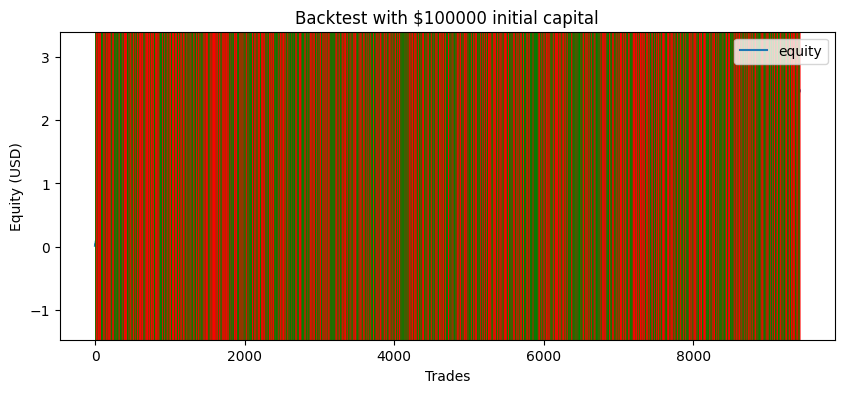

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import load

# Load the model from the file
loaded_model = load('nexo_xgb.joblib')

# Load the new testing dataset
new_test_data = pd.read_csv('../datasets/EURUSD_M1_LARGE_data.csv')

# Convert 'time' column to datetime
new_test_data['time'] = pd.to_datetime(new_test_data['time'])

# Filter the dataset to only include rows between 1:00 PM and 9:00 PM GMT
new_test_data = new_test_data[(new_test_data['time'].dt.time >= pd.Timestamp('13:00').time()) & 
                              (new_test_data['time'].dt.time <= pd.Timestamp('21:00').time())]

# Preprocess the new test data to match the training data preprocessing steps

# Normalize 'Adj Close' value
new_test_data['Adj Close'] = new_test_data['close']
new_test_data['return'] = new_test_data['Adj Close'] - new_test_data['Adj Close'].shift(1)
return_range = new_test_data['return'].max() - new_test_data['return'].min()
new_test_data['return'] = new_test_data['return'] / return_range

# Make label (1 as rising price, 0 as falling price)
new_test_data['label'] = new_test_data['return'].shift(-1)
new_test_data['label'] = new_test_data['label'].apply(lambda x: 1 if x > 0.0 else 0)
new_test_data.dropna(inplace=True)

# Extract features and labels for the test set
n_features = 60  # number of features

test_x = np.array([]).reshape([-1, n_features])
test_y = np.array([]).reshape([-1, 1])
trade_times = []  # To store the corresponding times for each trade

for index, row in new_test_data.iterrows():
    i = new_test_data.index.get_loc(index)
    if i < n_features:
        continue

    _x = np.array(new_test_data[i - n_features + 1:i + 1]['return']).T.reshape([1, -1])
    _y = new_test_data.iloc[i]['label']
    test_x = np.vstack((test_x, _x))
    test_y = np.vstack((test_y, _y))
    # Store the corresponding time for the trade
    trade_times.append(new_test_data.iloc[i]['time'])

test_y = test_y.reshape([-1])

# Make predictions with the loaded model
predictions = loaded_model.predict(test_x)

# Parameters
trade_amount = 100.0
commission = 0.0
stop_loss = 0.01  # Example stop-loss at 2%
take_profit = 0.01  # Example take-profit at 5%

# DataFrame to store trade data
df_trade = pd.DataFrame(test_x[:, -1], columns=['return'])
df_trade['pred'] = predictions
df_trade['label'] = test_y
df_trade['won'] = df_trade['label'] == df_trade['pred']
df_trade['return'] = df_trade['return'].shift(-1) * return_range
df_trade.drop(df_trade.index[len(df_trade) - 1], inplace=True)
# Ensure the lengths of trade_times and df_trade match
trade_times = trade_times[:len(df_trade)]  # Trim trade_times if it has extra elements
df_trade['time'] = trade_times  # Add the time of trade execution

def calc_profit(row):
    trade_return = row['return']
    
    # Apply stop-loss
    if trade_return <= -stop_loss:
        pnl = -stop_loss * trade_amount - commission
    # Apply take-profit
    elif trade_return >= take_profit:
        pnl = take_profit * trade_amount - commission
    else:
        # Regular calculation
        if row['won']:
            pnl = abs(trade_return) * trade_amount - commission
        else:
            pnl = -abs(trade_return) * trade_amount - commission
    
    return pnl

# Calculate profit and equity
df_trade['pnl'] = df_trade.apply(lambda row: calc_profit(row), axis=1)
df_trade['equity'] = df_trade['pnl'].cumsum()

# Display the last few rows of the DataFrame
display(df_trade.tail())

# Plot equity curve
df_trade.plot(y='equity', figsize=(10, 4), title='Backtest with $100000 initial capital')
plt.xlabel('Trades')
plt.ylabel('Equity (USD)')

# Highlight trades on the plot
for r in df_trade.iterrows():
    if r[1]['won']:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='g')
    else:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='r')

plt.show()


Net Profit            : $2.47
Total win volume      : 65
Total loss volume     : -63
Number Winning Trades : 4523
Number Losing Trades  : 4543
Percent Profitable    : 49.89%
Avg Win Trade         : $0.015
Avg Los Trade         : $-0.014
Largest Win Trade     : $0.591
Largest Los Trade     : $-1.000
Profit Factor         : 1.04


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9320\2939523137.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])


<Axes: >

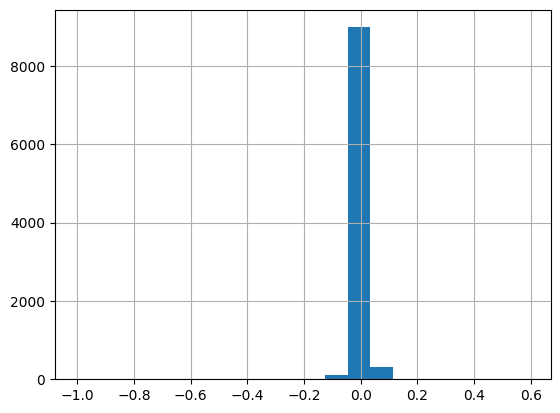

In [68]:
# Calculate summary of trades
n_win_trades = float(df_trade[df_trade['pnl']>0.0]['pnl'].count())
n_los_trades = float(df_trade[df_trade['pnl']<0.0]['pnl'].count())
win_vol = df_trade[df_trade['pnl']>0.0]['pnl'].mean() * n_win_trades
loss_vol = df_trade[df_trade['pnl']<0.0]['pnl'].mean() * n_los_trades
# risk_exposure = df_trade['risk'].sum()
print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])
# print("Risk Exposure         : %d" % risk_exposure)
print("Total win volume      : %d" % win_vol)
print("Total loss volume     : %d" % loss_vol)
print("Number Winning Trades : %d" % n_win_trades)
print("Number Losing Trades  : %d" % n_los_trades)
print("Percent Profitable    : %.2f%%" % (100*n_win_trades/(n_win_trades + n_los_trades)))
print("Avg Win Trade         : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].mean())
print("Avg Los Trade         : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].mean())
print("Largest Win Trade     : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].max())
print("Largest Los Trade     : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].min())
print("Profit Factor         : %.2f" % abs(df_trade[df_trade['pnl']>0.0]['pnl'].sum()/df_trade[df_trade['pnl']<0.0]['pnl'].sum()))

df_trade['pnl'].hist(bins=20)

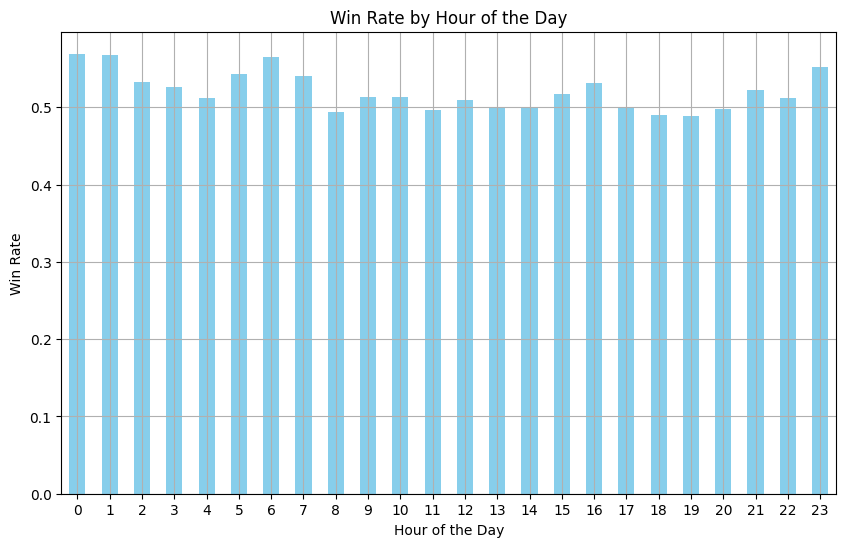

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column (you can adjust to group by other time intervals)
df_trade['hour'] = df_trade['time'].dt.hour

# Group by hour and calculate the win rate for each hour
hourly_win_rate = df_trade.groupby('hour')['won'].mean()

# Plot the win rate by hour
plt.figure(figsize=(10, 6))
hourly_win_rate.plot(kind='bar', color='skyblue')
plt.title('Win Rate by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Win Rate')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

# Alternatively, if you want to analyze by specific time intervals (e.g., 30-minute intervals), you can do:
# df_trade['half_hour'] = df_trade['time'].dt.floor('30T')  # This groups by 30-minute intervals
# half_hour_win_rate = df_trade.groupby('half_hour')['won'].mean()

# # Plot the win rate by 30-minute interval
# plt.figure(figsize=(12, 6))
# half_hour_win_rate.plot(kind='bar', color='skyblue')
# plt.title('Win Rate by 30-Minute Interval')
# plt.xlabel('Time Interval')
# plt.ylabel('Win Rate')
# plt.xticks(rotation=45)
# plt.grid(True)
# plt.show()


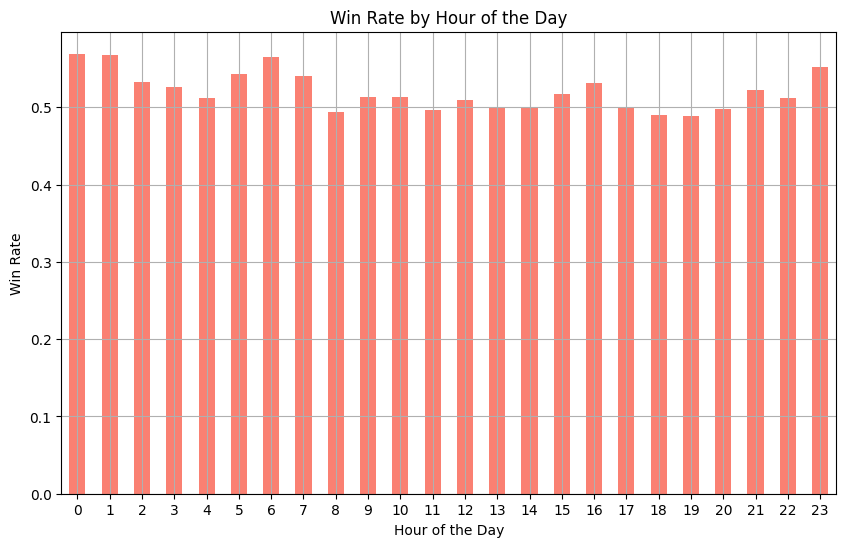

In [50]:
# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column (you can adjust to group by other time intervals)
df_trade['hour'] = df_trade['time'].dt.hour

# Group by hour and calculate the win rate for each hour
hourly_win_rate = df_trade.groupby('hour')['won'].mean()

# Plot the win rate by hour
plt.figure(figsize=(10, 6))
hourly_win_rate.plot(kind='bar', color='salmon')
plt.title('Win Rate by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Win Rate')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

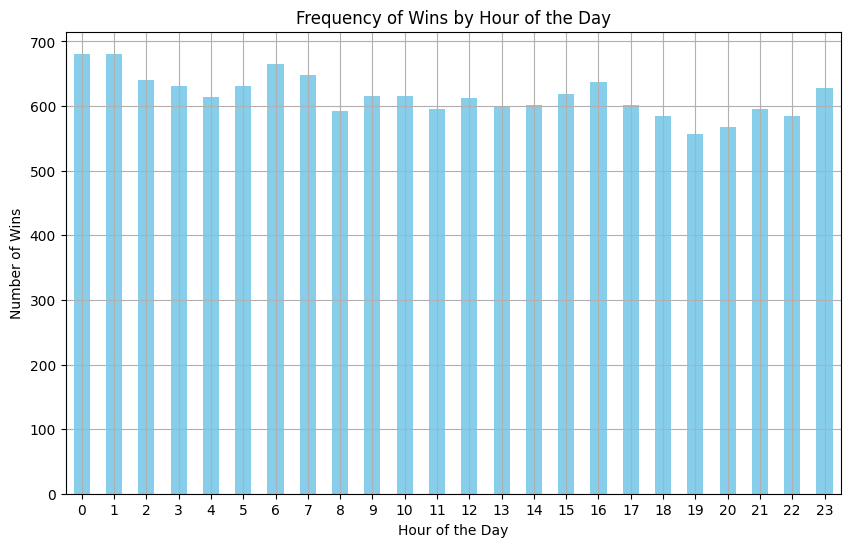

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Count the frequency of wins (won == True) for each hour
hourly_win_count = df_trade[df_trade['won'] == True].groupby('hour').size()

# Plot the frequency of wins by hour
plt.figure(figsize=(10, 6))
hourly_win_count.plot(kind='bar', color='skyblue')
plt.title('Frequency of Wins by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Wins')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()


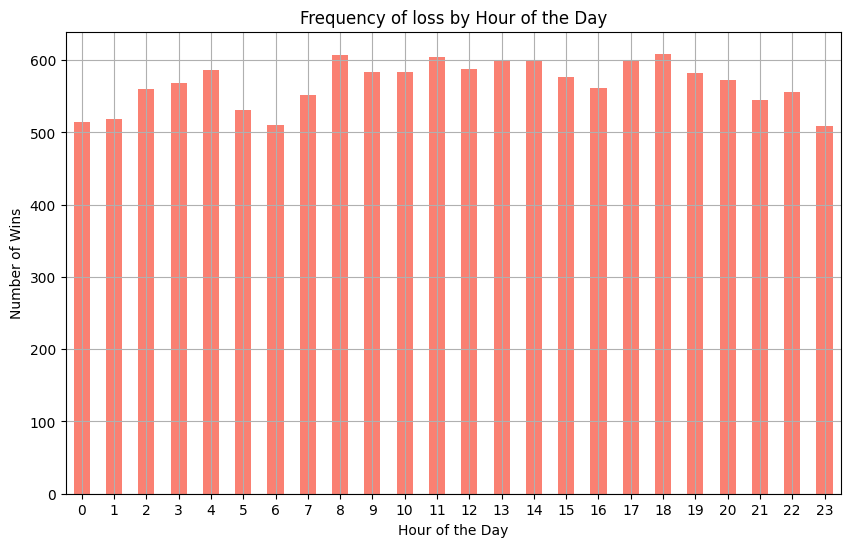

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Count the frequency of wins (won == False) for each hour
hourly_win_count = df_trade[df_trade['won'] == False].groupby('hour').size()

# Plot the frequency of wins by hour
plt.figure(figsize=(10, 6))
hourly_win_count.plot(kind='bar', color='salmon')
plt.title('Frequency of loss by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Wins')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()


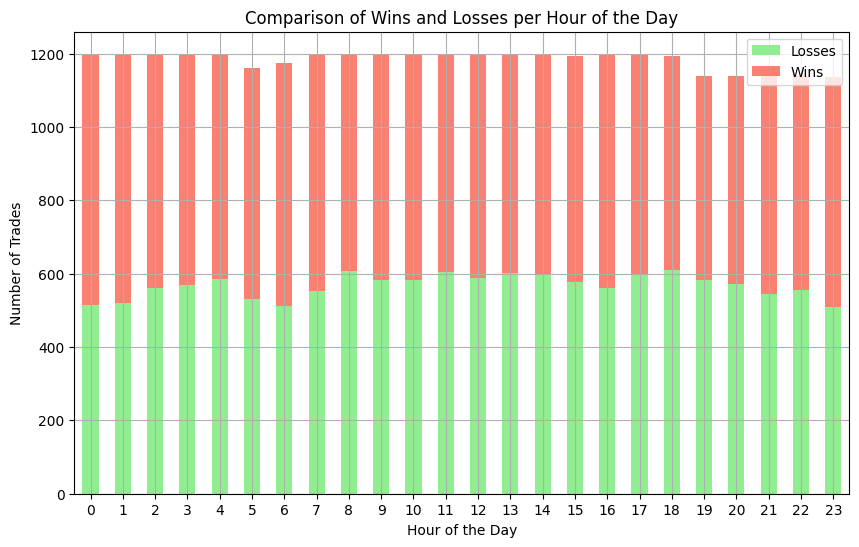

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Group by hour and count the wins and losses
hourly_win_loss = df_trade.groupby(['hour', 'won']).size().unstack(fill_value=0)

# Plot the comparison of wins and losses per hour
hourly_win_loss.plot(kind='bar', figsize=(10, 6), stacked=True, color=['lightgreen', 'salmon'])
plt.title('Comparison of Wins and Losses per Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trades')
plt.xticks(rotation=0)
plt.legend(['Losses', 'Wins'])
plt.grid(True)
plt.show()


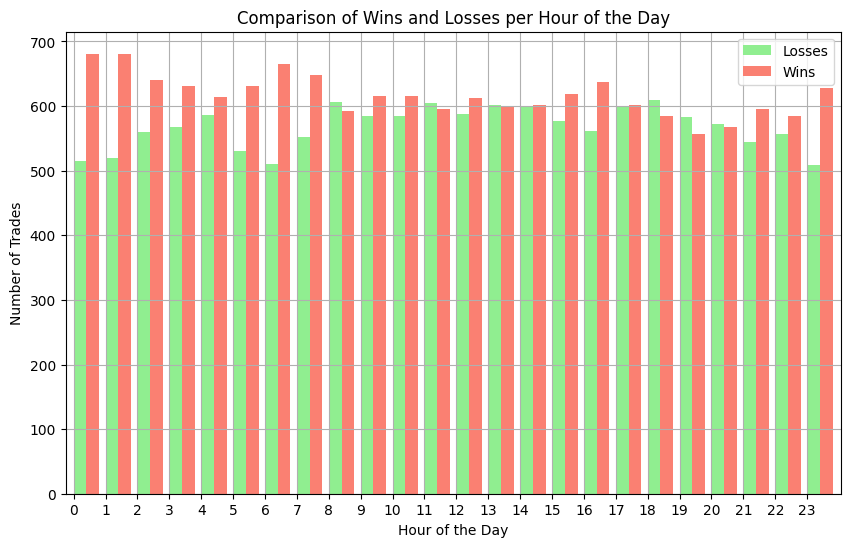

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Group by hour and count the wins and losses
hourly_win_loss = df_trade.groupby(['hour', 'won']).size().unstack(fill_value=0)

# Plot the comparison of wins and losses per hour side by side
ax = hourly_win_loss.plot(kind='bar', figsize=(10, 6), position=0, width=0.8, color=['lightgreen', 'salmon'])


plt.title('Comparison of Wins and Losses per Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trades')
plt.xticks(rotation=0)
plt.legend(['Losses', 'Wins'])
plt.grid(True)
plt.show()


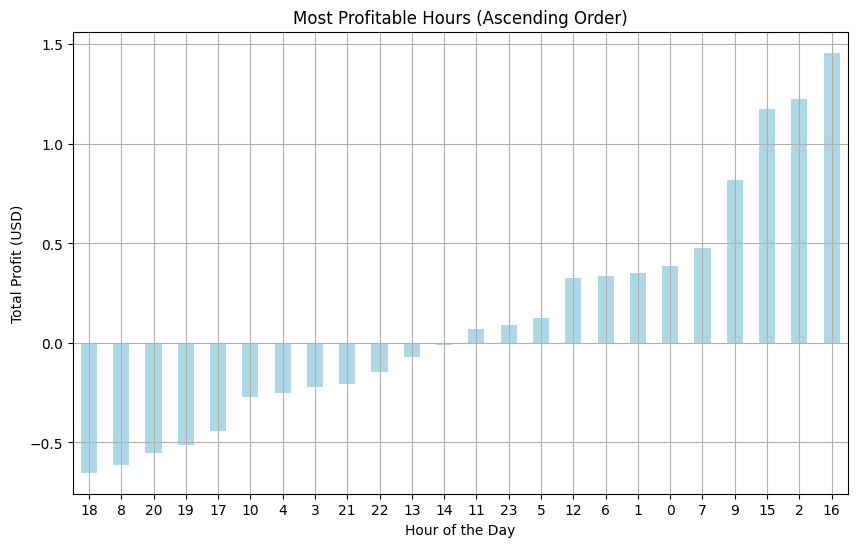

hour
18   -0.652
8    -0.613
20   -0.553
19   -0.511
17   -0.442
10   -0.273
4    -0.252
3    -0.223
21   -0.204
22   -0.148
13   -0.069
14   -0.010
11    0.068
23    0.090
5     0.124
12    0.326
6     0.335
1     0.352
0     0.387
7     0.475
9     0.819
15    1.175
2     1.225
16    1.458
Name: pnl, dtype: float64


In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Group by hour and calculate the total profit for each hour
hourly_profit = df_trade.groupby('hour')['pnl'].sum()

# Sort the hours by profit in ascending order
hourly_profit_sorted = hourly_profit.sort_values(ascending=True)

# Plot the most profitable hours
plt.figure(figsize=(10, 6))
hourly_profit_sorted.plot(kind='bar', color='lightblue')
plt.title('Most Profitable Hours (Ascending Order)')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Profit (USD)')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

# Display the sorted hours and their profits
print(hourly_profit_sorted)


In [61]:
import pandas as pd

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Convert 'won' column to int (True=1, False=0)
df_trade['won_int'] = df_trade['won'].astype(int)

# Group by hour and count the number of wins and losses
hourly_counts = df_trade.groupby('hour')['won_int'].value_counts().unstack(fill_value=0)

# Filter hours where wins are greater than losses
hours_with_more_wins = hourly_counts[1] > hourly_counts[0]

# Get the total profit and loss for these hours
df_trade_filtered = df_trade[df_trade['hour'].isin(hours_with_more_wins.index[hours_with_more_wins])]

# Calculate total profit and loss
total_profit = df_trade_filtered[df_trade_filtered['won'] == True]['pnl'].sum()
total_loss = df_trade_filtered[df_trade_filtered['won'] == False]['pnl'].sum()

# Print the results
print(f"Total Profit for hours with more winning trades: {total_profit:.2f}")
print(f"Total Loss for hours with more losing trades: {total_loss:.2f}")


Total Profit for hours with more winning trades: 109.60
Total Loss for hours with more losing trades: -104.39


In [62]:
import pandas as pd

# Assuming df_trade is your DataFrame with trade data

# Ensure that 'time' is in datetime format
df_trade['time'] = pd.to_datetime(df_trade['time'])

# Extract hour from the 'time' column
df_trade['hour'] = df_trade['time'].dt.hour

# Convert 'won' column to int (True=1, False=0)
df_trade['won_int'] = df_trade['won'].astype(int)

# Group by hour and count the number of wins and losses
hourly_counts = df_trade.groupby('hour')['won_int'].value_counts().unstack(fill_value=0)

# Filter hours where wins are greater than losses
hours_with_more_wins = hourly_counts[1] > hourly_counts[0]

# Get the total profit and loss for these hours
df_trade_filtered = df_trade[df_trade['hour'].isin(hours_with_more_wins.index[hours_with_more_wins])]

# Calculate total profit and total loss
total_profit = df_trade_filtered[df_trade_filtered['won'] == True]['pnl'].sum()
total_loss = df_trade_filtered[df_trade_filtered['won'] == False]['pnl'].sum()

# Calculate net profit (profit minus loss)
net_profit = total_profit + total_loss  # Since losses are negative, this effectively subtracts them

# Print the results
print(f"Total Profit for hours with more winning trades: {total_profit:.2f}")
print(f"Total Loss for hours with more losing trades: {total_loss:.2f}")
print(f"Net Profit/Loss: {net_profit:.2f}")


Total Profit for hours with more winning trades: 109.60
Total Loss for hours with more losing trades: -104.39
Net Profit/Loss: 5.21


In [ ]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from datetime import datetime
import time
import joblib
import logging

# Configure logging
logging.basicConfig(filename='trading_log.log', level=logging.DEBUG, format='%(asctime)s %(levelname)s: %(message)s')

# Initialize MetaTrader 5
if not mt5.initialize():
    logging.error("initialize() failed")
    mt5.shutdown()

# Define the symbol and timeframe
symbol = "EURUSD"
timeframe = mt5.TIMEFRAME_M1

# Load trained model
model_path = "nexo_xgb.joblib"
loaded_model = joblib.load(model_path)

# Risk management parameters
max_open_trades = 5  # Maximum allowed open trades
max_loss_threshold = -100  # Stop trading if equity drops below this threshold
min_stop_loss_pips = 10  # Minimum stop-loss distance in pips

def calculate_atr(symbol, timeframe, period=14):
    """Calculate the Average True Range (ATR) for dynamic stop loss."""
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, period + 1)
    if rates is None:
        logging.error("Failed to fetch ATR data")
        return None
    
    rates_frame = pd.DataFrame(rates)
    rates_frame['true_range'] = rates_frame[['high', 'low', 'close']].apply(lambda x: max(x) - min(x), axis=1)
    atr = rates_frame['true_range'].rolling(period).mean().iloc[-1]
    return atr

def check_open_trades(symbol):
    """Check the number of open trades for the given symbol."""
    positions = mt5.positions_get(symbol=symbol)
    return len(positions) if positions else 0

def place_trade(symbol, action, lot=0.1, slippage=5, atr_multiplier=2, take_profit=10):
    """Place trade with ATR-based stop loss."""
    point = mt5.symbol_info(symbol).point
    price = mt5.symbol_info_tick(symbol).ask if action == "BUY" else mt5.symbol_info_tick(symbol).bid
    deviation = slippage
    
    atr_value = calculate_atr(symbol, mt5.TIMEFRAME_M1)
    if atr_value is None:
        logging.warning("ATR calculation failed, skipping trade.")
        return
    
    stop_loss = atr_value * atr_multiplier  
    # Ensure stop-loss is at least 10 pips
    stop_loss = max(stop_loss, min_stop_loss_pips * point)
    
    sl_price = price - stop_loss if action == "BUY" else price + stop_loss
    tp_price = price + take_profit * point if action == "BUY" else price - take_profit * point
    
    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": lot,
        "type": mt5.ORDER_TYPE_BUY if action == "BUY" else mt5.ORDER_TYPE_SELL,
        "price": price,
        "sl": sl_price,
        "tp": tp_price,
        "deviation": deviation,
        "magic": 234000,
        "comment": "Automated trade",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_RETURN,
    }
    
    print(request)
    result = mt5.order_send(request)
    print(result)
    if result.retcode != mt5.TRADE_RETCODE_DONE:
        logging.error(f"Trade failed, retcode={result.retcode}, details={result}")
    else:
        logging.info(f"Trade successful: {action} {lot} lot of {symbol} at {price}, SL={sl_price}, TP={tp_price}")

def fetch_and_preprocess_data():
    """Fetch market data and preprocess it for model input."""
    logging.debug("Fetching market data...")
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, 1000)
    if rates is None:
        logging.error("Failed to fetch market data")
        return None
    
    rates_frame = pd.DataFrame(rates)
    rates_frame['time'] = pd.to_datetime(rates_frame['time'], unit='s')
    rates_frame['return'] = rates_frame['close'].diff()
    return_range = rates_frame['return'].max() - rates_frame['return'].min()
    
    if return_range == 0:
        logging.warning("Return range is zero, skipping this iteration.")
        return None
    
    rates_frame['return'] = rates_frame['return'] / return_range
    rates_frame['label'] = rates_frame['return'].shift(-1).apply(lambda x: 1 if x > 0.0 else 0)
    rates_frame.dropna(inplace=True)
    return rates_frame

def prepare_features(data, n_features):
    """Prepare feature data for prediction."""
    if len(data) < n_features:
        logging.warning("Not enough data to prepare features.")
        return np.array([])
    return np.array([data['return'].iloc[i-n_features:i].values for i in range(n_features, len(data))])

def monitor_and_close_trades(symbol):
    """
    Monitor open trades and close them if they hit their stop-loss or take-profit levels.
    """
    # Fetch all open positions for the specified symbol
    positions = mt5.positions_get(symbol=symbol)
    if positions is None:
        logging.error("Failed to fetch open positions.")
        return
    
    for position in positions:
        position_id = position.ticket
        position_type = position.type
        open_price = position.price_open
        current_price = mt5.symbol_info_tick(symbol).bid if position_type == mt5.ORDER_TYPE_BUY else mt5.symbol_info_tick(symbol).ask
        stop_loss = position.sl
        take_profit = position.tp
        
        # Check if the current price has hit the stop-loss or take-profit
        if (position_type == mt5.ORDER_TYPE_BUY and (current_price <= stop_loss or current_price >= take_profit)) or \
           (position_type == mt5.ORDER_TYPE_SELL and (current_price >= stop_loss or current_price <= take_profit)):
            # Close the trade
            close_request = {
                "action": mt5.TRADE_ACTION_DEAL,
                "symbol": symbol,
                "volume": position.volume,
                "type": mt5.ORDER_TYPE_SELL if position_type == mt5.ORDER_TYPE_BUY else mt5.ORDER_TYPE_BUY,
                "position": position_id,
                "price": current_price,
                "deviation": 10,
                "magic": 234000,
                "comment": "Auto close",
                "type_time": mt5.ORDER_TIME_GTC,
                "type_filling": mt5.ORDER_FILLING_IOC,
            }
            
            result = mt5.order_send(close_request)
            if result.retcode != mt5.TRADE_RETCODE_DONE:
                logging.error(f"Failed to close trade {position_id}, retcode={result.retcode}, details={result}")
            else:
                logging.info(f"Trade {position_id} closed successfully at {current_price}")

# Automated trading loop
n_features = 60
while True:
    try:
        # Monitor and close trades
        monitor_and_close_trades(symbol)
        
        # Fetch and preprocess data
        rates_frame = fetch_and_preprocess_data()
        if rates_frame is None:
            logging.debug("No data fetched, sleeping for 30 seconds.")
            time.sleep(30)
            continue
        
        # Prepare features and make predictions
        train_x = prepare_features(rates_frame, n_features)
        if train_x.size == 0:
            logging.debug("Not enough features, sleeping for 30 seconds.")
            time.sleep(30)
            continue
        
        predictions = loaded_model.predict(train_x)
        latest_prediction = predictions[-1]
        
        # Check open trades and risk management
        open_trades = check_open_trades(symbol)
        logging.debug(f"Number of open trades: {open_trades}")
        if open_trades >= max_open_trades:
            logging.warning("Maximum number of open trades reached.")
            time.sleep(30)
            continue
        
        account_info = mt5.account_info()
        if account_info.equity - account_info.balance <= max_loss_threshold:
            logging.warning("Maximum loss threshold exceeded. Halting trading.")
            break
        
        # Place new trades based on predictions
        if latest_prediction == 0:
            logging.debug("Prediction is BUY.")
            place_trade(symbol, "BUY")
        else:
            logging.debug("Prediction is SELL.")
            place_trade(symbol, "SELL")
        
        time.sleep(30)
    except Exception as e:
        logging.error(f"An error occurred: {e}")
        time.sleep(60)

# Shutdown MetaTrader 5
mt5.shutdown()

{'action': 1, 'symbol': 'EURUSD', 'volume': 0.1, 'type': 0, 'price': 1.05185, 'sl': 1.0513785714285713, 'tp': 1.05195, 'deviation': 5, 'magic': 234000, 'comment': 'Automated trade', 'type_time': 0, 'type_filling': 2}
OrderSendResult(retcode=10009, deal=52010250754, order=52054545904, volume=0.1, price=1.05185, bid=1.05182, ask=1.05186, comment='Request executed', request_id=3012599140, retcode_external=0, request=TradeRequest(action=1, magic=234000, order=0, symbol='EURUSD', volume=0.1, price=1.05185, stoplimit=0.0, sl=1.0513785714285713, tp=1.05195, deviation=5, type=0, type_filling=2, type_time=0, expiration=0, comment='Automated trade', position=0, position_by=0))
{'action': 1, 'symbol': 'EURUSD', 'volume': 0.1, 'type': 0, 'price': 1.05206, 'sl': 1.0515585714285713, 'tp': 1.05216, 'deviation': 5, 'magic': 234000, 'comment': 'Automated trade', 'type_time': 0, 'type_filling': 2}
OrderSendResult(retcode=10009, deal=52010254000, order=52054549100, volume=0.1, price=1.05206, bid=1.052010

In [1]:
import MetaTrader5 as mt5


# Initialize MetaTrader 5
if not mt5.initialize():
    logging.error("initialize() failed")
    mt5.shutdown()

# Configuration
symbol = "EURUSD"

# Fetch Symbol Information
symbol_info = mt5.symbol_info(symbol)
print(symbol_info)
if symbol_info is None:
    mt5.shutdown()
    exit()

SymbolInfo(custom=False, chart_mode=0, select=True, visible=True, session_deals=0, session_buy_orders=0, session_sell_orders=0, volume=0, volumehigh=0, volumelow=0, time=1738002168, digits=5, spread=4, spread_float=True, ticks_bookdepth=10, trade_calc_mode=0, trade_mode=4, start_time=0, expiration_time=0, trade_stops_level=0, trade_freeze_level=0, trade_exemode=1, swap_mode=1, swap_rollover3days=3, margin_hedged_use_leg=False, expiration_mode=15, filling_mode=1, order_mode=127, order_gtc_mode=0, option_mode=0, option_right=0, bid=1.05054, bidhigh=1.0533, bidlow=1.04539, ask=1.05058, askhigh=1.05335, asklow=1.04543, last=0.0, lasthigh=0.0, lastlow=0.0, volume_real=0.0, volumehigh_real=0.0, volumelow_real=0.0, option_strike=0.0, point=1e-05, trade_tick_value=1.0, trade_tick_value_profit=1.0, trade_tick_value_loss=1.0, trade_tick_size=1e-05, trade_contract_size=100000.0, trade_accrued_interest=0.0, trade_face_value=0.0, trade_liquidity_rate=0.0, volume_min=0.01, volume_max=500.0, volume_s

In [2]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone
import time
import joblib
import logging

# Configure logging
logging.basicConfig(filename='trading_log.log', level=logging.DEBUG, 
                    format='%(asctime)s %(levelname)s: %(message)s')

# Initialize MetaTrader 5
if not mt5.initialize():
    logging.error("initialize() failed")
    mt5.shutdown()

# Configuration
symbol = "EURUSD"
timeframe = mt5.TIMEFRAME_M1
model_path = "nexo_xgb.joblib"
loaded_model = joblib.load(model_path)

# Fetch Symbol Information
symbol_info = mt5.symbol_info(symbol)
if symbol_info is None:
    logging.error(f"Failed to retrieve symbol info for {symbol}")
    mt5.shutdown()
    exit()

# Extract key attributes from SymbolInfo
point = symbol_info.point
spread = symbol_info.spread * point
contract_size = symbol_info.trade_contract_size
trade_tick_value = symbol_info.trade_tick_value
volume_min = symbol_info.volume_min
volume_max = symbol_info.volume_max
volume_step = symbol_info.volume_step
swap_long = symbol_info.swap_long
swap_short = symbol_info.swap_short
bid = symbol_info.bid
ask = symbol_info.ask

# Triple Barrier Parameters
profit_multiplier = 1.0    # ATR multiplier for profit barrier
loss_multiplier = 1.0      # ATR multiplier for loss barrier
vertical_barrier_hours = 0.5  # Time barrier in hours
min_stop_loss_pips = 10     # Minimum stop loss distance
max_open_trades = 5
risk_reward_ratio = 2       # Minimum acceptable risk/reward ratio


def fetch_and_preprocess_data():
    """Fetch market data and preprocess it for model input."""
    logging.debug("Fetching market data...")
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, 1000)
    if rates is None:
        logging.error("Failed to fetch market data")
        return None
    
    rates_frame = pd.DataFrame(rates)
    rates_frame['time'] = pd.to_datetime(rates_frame['time'], unit='s')
    rates_frame['return'] = rates_frame['close'].diff()
    return_range = rates_frame['return'].max() - rates_frame['return'].min()
    
    if return_range == 0:
        logging.warning("Return range is zero, skipping this iteration.")
        return None
    
    rates_frame['return'] = rates_frame['return'] / return_range
    rates_frame['label'] = rates_frame['return'].shift(-1).apply(lambda x: 1 if x > 0.0 else 0)
    rates_frame.dropna(inplace=True)
    return rates_frame

def prepare_features(data, n_features):
    """Prepare feature data for prediction."""
    if len(data) < n_features:
        logging.warning("Not enough data to prepare features.")
        return np.array([])
    return np.array([data['return'].iloc[i-n_features:i].values for i in range(n_features, len(data))])


def check_open_trades(symbol):
    """Check the number of open trades for the given symbol."""
    positions = mt5.positions_get(symbol=symbol)
    return len(positions) if positions else 0

def calculate_true_atr(symbol, timeframe, period=14):
    """Calculate the True Average True Range (ATR)"""
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, period+1)
    if rates is None or len(rates) < period+1:
        logging.error("Failed to fetch ATR data")
        return None
    
    df = pd.DataFrame(rates)
    df['previous_close'] = df['close'].shift(1)
    df['TR1'] = df['high'] - df['low']
    df['TR2'] = abs(df['high'] - df['previous_close'])
    df['TR3'] = abs(df['low'] - df['previous_close'])
    df['TR'] = df[['TR1', 'TR2', 'TR3']].max(axis=1)
    return df['TR'].rolling(period).mean().iloc[-1]

def calculate_barriers(entry_price, atr, direction):
    """Calculate price barriers based on ATR and direction"""
    if direction == "BUY":
        return {
            'upper': entry_price + (atr * profit_multiplier),
            'lower': entry_price - (atr * loss_multiplier)
        }
    return {
        'upper': entry_price - (atr * loss_multiplier),
        'lower': entry_price + (atr * profit_multiplier)
    }

def validate_barriers(entry_price, barriers, direction):
    """Ensure barriers meet minimum risk/reward requirements"""
    point = mt5.symbol_info(symbol).point
    min_sl_distance = min_stop_loss_pips * point
    
    if direction == "BUY":
        sl_distance = entry_price - barriers['lower']
        tp_distance = barriers['upper'] - entry_price
    else:
        sl_distance = barriers['lower'] - entry_price
        tp_distance = entry_price - barriers['upper']

    # Enforce minimum stop loss
    if sl_distance < min_sl_distance:
        new_sl = entry_price - min_sl_distance if direction == "BUY" else entry_price + min_sl_distance
        barriers['lower'] = new_sl
        logging.info(f"Adjusted SL to minimum {min_stop_loss_pips} pips")

    # Validate risk/reward ratio
    if tp_distance / sl_distance < risk_reward_ratio:
        raise ValueError(f"Risk/reward ratio below {risk_reward_ratio}:1")
    
    return barriers


# Risk Management Parameters
risk_per_trade = 0.01  # 1% of account equity per trade
max_risk_ratio = 0.05  # Max 5% of equity at risk across all trades


def calculate_position_size(symbol, entry_price, stop_loss_price, direction):
    """
    Calculate dynamic position size based on:
    - Current account equity
    - Risk per trade percentage
    - Stop loss distance
    - Symbol volatility characteristics
    """
    # Get account information
    account_info = mt5.account_info()
    if not account_info:
        logging.error("Failed to get account info")
        return 0.0
    
    equity = account_info.equity
    if equity <= 0:
        logging.error("Invalid account equity")
        return 0.0

    # Calculate risk amount
    risk_amount = equity * risk_per_trade
    
    # Get symbol characteristics
    symbol_info = mt5.symbol_info(symbol)
    if not symbol_info:
        logging.error(f"Failed to get symbol info for {symbol}")
        return 0.0
    
    # Calculate stop loss in pips
    point = symbol_info.point
    pip_size = point * 10  # 1 pip = 10 points
    
    if direction == "BUY":
        sl_distance = entry_price - stop_loss_price
    else:
        sl_distance = stop_loss_price - entry_price
    
    sl_pips = sl_distance / pip_size
    
    # Calculate pip value
    tick_value = symbol_info.trade_tick_value
    tick_size = symbol_info.trade_tick_size
    
    if tick_size == 0:
        logging.error("Invalid tick size")
        return 0.0
    
    ticks_per_pip = pip_size / tick_size
    pip_value = tick_value * ticks_per_pip
    
    # Calculate position size
    if sl_pips <= 0 or pip_value <= 0:
        logging.error(f"Invalid calculation: SL pips={sl_pips}, Pip value={pip_value}")
        return 0.0
    
    try:
        lot_size = risk_amount / (sl_pips * pip_value)
    except ZeroDivisionError:
        logging.error("Division by zero in position size calculation")
        return 0.0

    # Normalize lot size to broker requirements
    lot_step = symbol_info.volume_step
    min_lot = symbol_info.volume_min
    max_lot = symbol_info.volume_max
    
    if lot_step > 0:
        lot_size = round(lot_size / lot_step) * lot_step
    
    # Apply min/max limits
    lot_size = max(min(lot_size, max_lot), min_lot)
    
    # Check maximum exposure
    current_exposure = sum(pos.volume for pos in mt5.positions_get(symbol=symbol))
    if (current_exposure + lot_size) * pip_value * sl_pips > equity * max_risk_ratio:
        logging.warning("Maximum risk threshold exceeded, reducing position size")
        available_risk = equity * max_risk_ratio - current_exposure * pip_value * sl_pips
        lot_size = available_risk / (pip_value * sl_pips)
        lot_size = max(min(round(lot_size / lot_step) * lot_step, max_lot), min_lot)

    return round(lot_size, 2)

def place_trade_old(symbol, action, lot=0.1, slippage=5, atr_multiplier=2, take_profit=10):
    """Place trade with ATR-based stop loss."""
    point = mt5.symbol_info(symbol).point
    price = mt5.symbol_info_tick(symbol).ask if action == "BUY" else mt5.symbol_info_tick(symbol).bid
    deviation = slippage
    
    atr_value = calculate_atr(symbol, mt5.TIMEFRAME_M1)
    if atr_value is None:
        logging.warning("ATR calculation failed, skipping trade.")
        return
    
    stop_loss = atr_value * atr_multiplier  
    # Ensure stop-loss is at least 10 pips
    stop_loss = max(stop_loss, min_stop_loss_pips * point)
    
    sl_price = price - stop_loss if action == "BUY" else price + stop_loss
    tp_price = price + take_profit * point if action == "BUY" else price - take_profit * point
    
    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": lot,
        "type": mt5.ORDER_TYPE_BUY if action == "BUY" else mt5.ORDER_TYPE_SELL,
        "price": price,
        "sl": sl_price,
        "tp": tp_price,
        "deviation": deviation,
        "magic": 234000,
        "comment": "Automated trade",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_RETURN,
    }
    
    result = mt5.order_send(request)
    if result.retcode != mt5.TRADE_RETCODE_DONE:
        logging.error(f"Trade failed, retcode={result.retcode}, details={result}")
    else:
        logging.info(f"Trade successful: {action} {lot} lot of {symbol} at {price}, SL={sl_price}, TP={tp_price}")


def place_trade(symbol, direction):
    """Execute trade with improved error handling"""
    if not mt5.initialize():
        logging.error("Failed to initialize MT5")
        return False
    account_info = mt5.account_info()
    symbol_info = mt5.symbol_info(symbol)
    # print(symbol_info)
    # print(account_info)
    if not account_info:
        logging.error("Failed to retrieve account info, check login")
        return False

    try:
        # Get symbol info first
        symbol_info = mt5.symbol_info(symbol)
        if not symbol_info:
            logging.error("Failed to get symbol info")
            return False

        # Get pricing data with rounding
        tick = mt5.symbol_info_tick(symbol)
        price = round(tick.ask if direction == "BUY" else tick.bid, symbol_info.digits)
        
        # Calculate volatility
        atr = calculate_true_atr(symbol, mt5.TIMEFRAME_H1)
        if atr is None:
            return False

        # Calculate barriers
        try:
            barriers = calculate_barriers(price, atr, direction)
            barriers = validate_barriers(price, barriers, direction)
        except ValueError as e:
            logging.warning(str(e))
            return False

        # Calculate position size
        stop_loss = barriers['lower'] if direction == "BUY" else barriers['upper']
        lot_size = calculate_position_size(symbol, price, stop_loss, direction)
        
        # Validate lot size
        if lot_size <= 0 or lot_size > symbol_info.volume_max:
            logging.error("Invalid trade parameters")
            return False

        # Prepare expiration time
        expiration = datetime.now(timezone.utc) + timedelta(hours=vertical_barrier_hours)
        
        # Build request
        request = {
            "action": mt5.TRADE_ACTION_DEAL,
            "symbol": symbol,
            "volume": round(lot_size, 2),
            "type": mt5.ORDER_TYPE_BUY if direction == "BUY" else mt5.ORDER_TYPE_SELL,
            "price": price,
            "sl": round(stop_loss), #, symbol_info.digits),
            "tp": round(barriers['upper'] if direction == "BUY" else barriers['lower'], symbol_info.digits),
            "deviation": 5,
            "magic": 234000,
            "comment": f"TB_{barriers['upper']:.5f}_{barriers['lower']:.5f}_{expiration.timestamp()}",
            "type_time": mt5.ORDER_TIME_GTC,
            "type_filling": mt5.ORDER_FILLING_RETURN,
            "expiration": int(expiration.timestamp())
        }
        print(request)
        # Execute trade
        result = mt5.order_send(request)
        print(result)
        # Handle result codes
        if result.retcode != mt5.TRADE_RETCODE_DONE:
            error_msg = mt5.last_error()
            logging.error(f"Trade failed: {error_msg}")
            logging.error(f"Broker response: {result}")
            return False
            
        return True

    except Exception as e:
        logging.error(f"Critical error in place_trade: {str(e)}")
        return False
    
def monitor_and_close_trades():
    """Monitor trades for barrier hits"""
    positions = mt5.positions_get(symbol=symbol)
    if not positions:
        return

    current_price = mt5.symbol_info_tick(symbol).bid
    now = datetime.now()

    for position in positions:
        comment = position.comment.split('_')
        if len(comment) < 4 or comment[0] != "TB":
            continue  # Skip non-TB trades

        upper_barrier = float(comment[1])
        lower_barrier = float(comment[2])
        expiration = datetime.fromtimestamp(int(comment[3]))

        close_trade = False
        reason = ""
        
        # Check price barriers
        if (position.type == mt5.ORDER_TYPE_BUY and 
            (current_price >= upper_barrier or current_price <= lower_barrier)):
            reason = "TP hit" if current_price >= upper_barrier else "SL hit"
            close_trade = True
            
        elif (position.type == mt5.ORDER_TYPE_SELL and 
              (current_price <= upper_barrier or current_price >= lower_barrier)):
            reason = "TP hit" if current_price <= upper_barrier else "SL hit"
            close_trade = True
            
        # Check time barrier
        if now >= expiration:
            reason = "Time barrier"
            close_trade = True

        if close_trade:
            close_position(position, reason)

def close_position(position, reason):
    """Close specified position"""
    tick = mt5.symbol_info_tick(symbol)
    price = tick.ask if position.type == mt5.ORDER_TYPE_BUY else tick.bid
    
    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": position.volume,
        "type": mt5.ORDER_TYPE_SELL if position.type == mt5.ORDER_TYPE_BUY else mt5.ORDER_TYPE_BUY,
        "position": position.ticket,
        "price": price,
        "deviation": 5,
        "magic": 234000,
        "comment": f"Closed: {reason}",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC
    }

    result = mt5.order_send(request)
    if result.retcode == mt5.TRADE_RETCODE_DONE:
        logging.info(f"Closed trade {position.ticket} ({reason}) at {price}")
    else:
        logging.error(f"Failed to close trade {position.ticket}: {result}")

# Trading loop
while True:
    try:
        monitor_and_close_trades()
        # print('cp 1')
        if check_open_trades(symbol) >= max_open_trades:
            time.sleep(60)
            # print('cp 2')
            continue

        # Data fetching and prediction logic
        data = fetch_and_preprocess_data()
        # print('cp 3')
        if data is not None:
            features = prepare_features(data, n_features=60)
            # print('cp 4')
            if features.size > 0:
                prediction = loaded_model.predict(features[-1].reshape(1, -1))
                if prediction[0] == 1:
                    # print('cp 5')
                    place_trade(symbol, "BUY")
                else:
                    place_trade(symbol, "SELL")
                    # print('cp 6')

        time.sleep(30)
        # print('cp 7')
        
    except Exception as e:
        logging.error(f"Critical error: {str(e)}")
        time.sleep(300)

mt5.shutdown()

KeyboardInterrupt: 

In [15]:
import MetaTrader5 as mt5
import pandas as pd
from datetime import datetime

# Initialize MetaTrader 5
if not mt5.initialize():
    print("initialize() failed")
    mt5.shutdown()

# Define the symbol and time range
symbol = "EURUSD"
start_date = datetime(2025, 1, 21)  # Adjust to your specific start date
end_date = datetime(2025, 1, 22)    # Adjust to your specific end date

# Fetch the trade history
history = mt5.history_deals_get(start_date, end_date, group=symbol)


In [16]:
history

(TradeDeal(ticket=51990256873, order=52034573946, time=1737466805, time_msc=1737466805072, type=0, entry=0, magic=234000, position_id=52034573946, reason=3, volume=0.1, price=1.03465, commission=0.0, swap=0.0, profit=0.0, fee=0.0, symbol='EURUSD', comment='Automated trade', external_id=''),
 TradeDeal(ticket=51990259443, order=52034576501, time=1737466835, time_msc=1737466835403, type=0, entry=0, magic=234000, position_id=52034576501, reason=3, volume=0.1, price=1.03473, commission=0.0, swap=0.0, profit=0.0, fee=0.0, symbol='EURUSD', comment='Automated trade', external_id=''),
 TradeDeal(ticket=51990261318, order=52034578379, time=1737466865, time_msc=1737466865851, type=0, entry=0, magic=234000, position_id=52034578379, reason=3, volume=0.1, price=1.03474, commission=0.0, swap=0.0, profit=0.0, fee=0.0, symbol='EURUSD', comment='Automated trade', external_id=''),
 TradeDeal(ticket=51990262642, order=52034579726, time=1737466896, time_msc=1737466896189, type=0, entry=0, magic=234000, po

In [17]:
if history is None:
    print("No deals found, error code =", mt5.last_error())

else:
    # Convert history to DataFrame
    history_df = pd.DataFrame(list(history), columns=history[0]._asdict().keys())
    history_df['time'] = pd.to_datetime(history_df['time'], unit='s')

    # Filter by symbol if necessary
    if symbol:
        history_df = history_df[history_df['symbol'] == symbol]

    # Display the DataFrame
    print(history_df)

# Shutdown MetaTrader 5
mt5.shutdown()


          ticket        order                time       time_msc  type  entry  \
0    51990256873  52034573946 2025-01-21 13:40:05  1737466805072     0      0   
1    51990259443  52034576501 2025-01-21 13:40:35  1737466835403     0      0   
2    51990261318  52034578379 2025-01-21 13:41:05  1737466865851     0      0   
3    51990262642  52034579726 2025-01-21 13:41:36  1737466896189     0      0   
4    51990264390  52034581508 2025-01-21 13:42:06  1737466926636     1      0   
..           ...          ...                 ...            ...   ...    ...   
469  51991031586  52035349247 2025-01-21 16:15:05  1737476105618     1      1   
470  51991031947  52035349620 2025-01-21 16:15:11  1737476111026     1      0   
471  51991047607  52035364919 2025-01-21 16:17:23  1737476243426     0      1   
472  51991047612  52035364925 2025-01-21 16:17:23  1737476243427     0      1   
473  51991068689  52035385971 2025-01-21 16:21:13  1737476473412     0      1   

      magic  position_id  r

True

In [18]:
df = history_df

In [19]:
# Convert the 'time' column to datetime format
df['time_formatted'] = pd.to_datetime(df['time'])
df

,ticket,order,time,time_msc,type,entry,magic,position_id,reason,volume,price,commission,swap,profit,fee,symbol,comment,external_id,time_formatted
0,51990256873,52034573946,2025-01-21 13:40:05,1737466805072,0,0,234000,52034573946,3,0.1,1.03465,0.0,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:40:05
1,51990259443,52034576501,2025-01-21 13:40:35,1737466835403,0,0,234000,52034576501,3,0.1,1.03473,0.0,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:40:35
2,51990261318,52034578379,2025-01-21 13:41:05,1737466865851,0,0,234000,52034578379,3,0.1,1.03474,0.0,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:41:05
3,51990262642,52034579726,2025-01-21 13:41:36,1737466896189,0,0,234000,52034579726,3,0.1,1.03472,0.0,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:41:36
4,51990264390,52034581508,2025-01-21 13:42:06,1737466926636,1,0,234000,52034581508,3,0.1,1.03465,0.0,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:42:06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,51991031586,52035349247,2025-01-21 16:15:05,1737476105618,1,1,234000,52035346687,5,0.1,1.03839,0.0,0.0,1.0,0.0,EURUSD,[tp 1.03839],,2025-01-21 16:15:05
470,51991031947,52035349620,2025-01-21 16:15:11,1737476111026,1,0,234000,52035349620,3,0.1,1.03833,0.0,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 16:15:11
471,51991047607,52035364919,2025-01-21 16:17:23,1737476243426,0,1,234000,52035339079,4,0.1,1.03863,0.0,0.0,-5.1,0.0,EURUSD,[sl 1.03863],,2025-01-21 16:17:23
472,51991047612,52035364925,2025-01-21 16:17:23,1737476243427,0,1,234000,52035341664,4,0.1,1.03859,0.0,0.0,-5.2,0.0,EURUSD,[sl 1.03859],,2025-01-21 16:17:23


In [20]:
df.profit.sum()

-88.1

In [21]:
# Create the new 'outcome' column based on the 'profit' column
df['outcome'] = df['profit'].apply(lambda x: 'profit' if x > 0 else ('loss' if x < 0 else 'no profit/loss'))

In [22]:
# Count the occurrences of each outcome
outcome_counts = df['outcome'].value_counts()

# Display the counts
print(outcome_counts)

outcome
no profit/loss    237
profit            178
loss               59
Name: count, dtype: int64


In [24]:
df['formatted_type'] = df['type'].apply(lambda x: 'buy' if x == 0 else 'sell')
# Count the occurrences of each outcome
outcome_counts = df['formatted_type'].value_counts()

# Display the counts
print(outcome_counts)

formatted_type
buy     237
sell    237
Name: count, dtype: int64


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

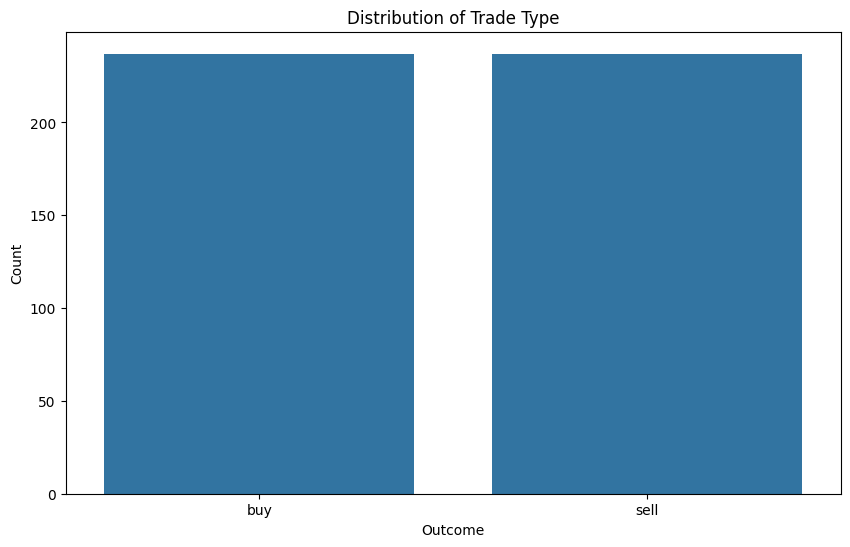

In [26]:
# Distribution of Trade Outcomes
plt.figure(figsize=(10, 6))
sns.countplot(x='formatted_type', data=df)
plt.title('Distribution of Trade Type')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()
# plt.savefig("output/fig1.png")

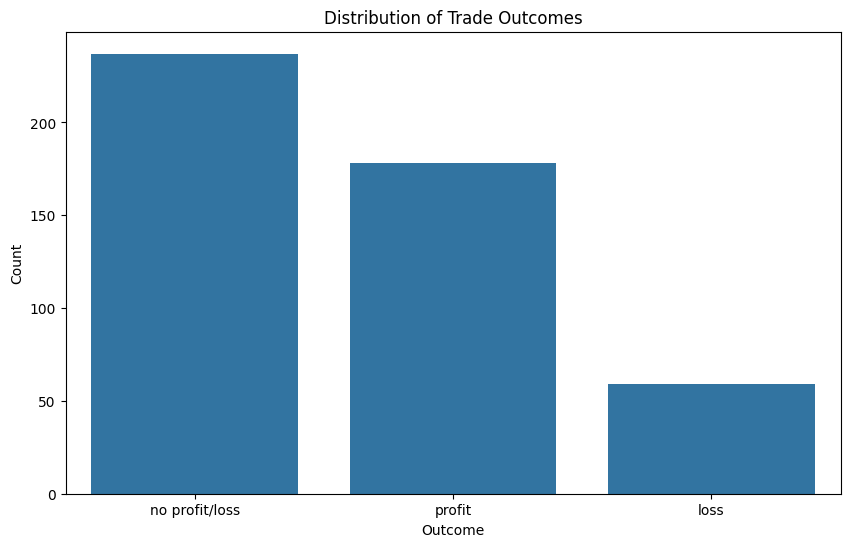

In [27]:

# Distribution of Trade Outcomes
plt.figure(figsize=(10, 6))
sns.countplot(x='outcome', data=df)
plt.title('Distribution of Trade Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()
# plt.savefig("output/fig1.jpeg")

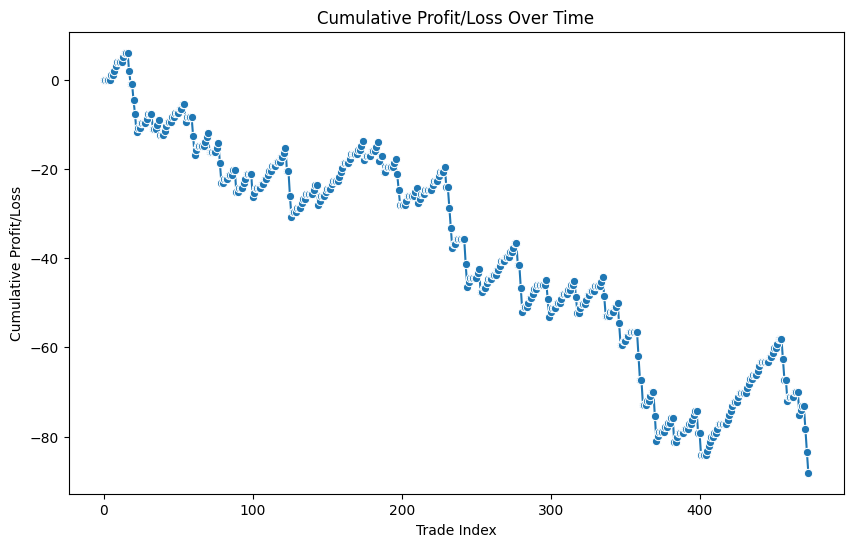

In [28]:
df['Cumulative_Profit_Loss'] = df['profit'].cumsum()
plt.figure(figsize=(10, 6))
sns.lineplot(x=df.index, y='Cumulative_Profit_Loss', data=df, marker='o')
plt.title('Cumulative Profit/Loss Over Time')
plt.xlabel('Trade Index')
plt.ylabel('Cumulative Profit/Loss')
plt.show()

In [29]:
df.head()

,ticket,order,time,time_msc,type,entry,magic,position_id,reason,volume,...,swap,profit,fee,symbol,comment,external_id,time_formatted,outcome,formatted_type,Cumulative_Profit_Loss
0,51990256873,52034573946,2025-01-21 13:40:05,1737466805072,0,0,234000,52034573946,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:40:05,no profit/loss,buy,0.0
1,51990259443,52034576501,2025-01-21 13:40:35,1737466835403,0,0,234000,52034576501,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:40:35,no profit/loss,buy,0.0
2,51990261318,52034578379,2025-01-21 13:41:05,1737466865851,0,0,234000,52034578379,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:41:05,no profit/loss,buy,0.0
3,51990262642,52034579726,2025-01-21 13:41:36,1737466896189,0,0,234000,52034579726,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:41:36,no profit/loss,buy,0.0
4,51990264390,52034581508,2025-01-21 13:42:06,1737466926636,1,0,234000,52034581508,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:42:06,no profit/loss,sell,0.0


In [30]:
df.isna().sum()

ticket                    0
order                     0
time                      0
time_msc                  0
type                      0
entry                     0
magic                     0
position_id               0
reason                    0
volume                    0
price                     0
commission                0
swap                      0
profit                    0
fee                       0
symbol                    0
comment                   0
external_id               0
time_formatted            0
outcome                   0
formatted_type            0
Cumulative_Profit_Loss    0
dtype: int64

In [31]:
count = df[df['comment'] == 'Automated trade'].shape[0]
count

237

In [32]:
df.shape

(474, 22)

In [33]:
# Create a new DataFrame with rows where the value in the 'comment' column is 'Automated trade'
trade_df = df[df['comment'] == 'Automated trade']


In [34]:
trade_df.shape

(237, 22)

In [35]:
trade_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 237 entries, 0 to 470
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ticket                  237 non-null    int64         
 1   order                   237 non-null    int64         
 2   time                    237 non-null    datetime64[ns]
 3   time_msc                237 non-null    int64         
 4   type                    237 non-null    int64         
 5   entry                   237 non-null    int64         
 6   magic                   237 non-null    int64         
 7   position_id             237 non-null    int64         
 8   reason                  237 non-null    int64         
 9   volume                  237 non-null    float64       
 10  price                   237 non-null    float64       
 11  commission              237 non-null    float64       
 12  swap                    237 non-null    float64       


In [36]:
trade_df.head()

,ticket,order,time,time_msc,type,entry,magic,position_id,reason,volume,...,swap,profit,fee,symbol,comment,external_id,time_formatted,outcome,formatted_type,Cumulative_Profit_Loss
0,51990256873,52034573946,2025-01-21 13:40:05,1737466805072,0,0,234000,52034573946,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:40:05,no profit/loss,buy,0.0
1,51990259443,52034576501,2025-01-21 13:40:35,1737466835403,0,0,234000,52034576501,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:40:35,no profit/loss,buy,0.0
2,51990261318,52034578379,2025-01-21 13:41:05,1737466865851,0,0,234000,52034578379,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:41:05,no profit/loss,buy,0.0
3,51990262642,52034579726,2025-01-21 13:41:36,1737466896189,0,0,234000,52034579726,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:41:36,no profit/loss,buy,0.0
4,51990264390,52034581508,2025-01-21 13:42:06,1737466926636,1,0,234000,52034581508,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 13:42:06,no profit/loss,sell,0.0


In [37]:
trade_df.tail()

,ticket,order,time,time_msc,type,entry,magic,position_id,reason,volume,...,swap,profit,fee,symbol,comment,external_id,time_formatted,outcome,formatted_type,Cumulative_Profit_Loss
462,51991021453,52035339079,2025-01-21 16:13:09,1737475989625,1,0,234000,52035339079,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 16:13:09,no profit/loss,sell,-71.1
463,51991024020,52035341664,2025-01-21 16:13:39,1737476019931,1,0,234000,52035341664,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 16:13:39,no profit/loss,sell,-71.1
465,51991026338,52035344003,2025-01-21 16:14:10,1737476050242,0,0,234000,52035344003,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 16:14:10,no profit/loss,buy,-70.1
466,51991028998,52035346687,2025-01-21 16:14:40,1737476080556,0,0,234000,52035346687,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 16:14:40,no profit/loss,buy,-70.1
470,51991031947,52035349620,2025-01-21 16:15:11,1737476111026,1,0,234000,52035349620,3,0.1,...,0.0,0.0,0.0,EURUSD,Automated trade,,2025-01-21 16:15:11,no profit/loss,sell,-73.1


In [38]:
trade_df.profit.sum()

0.0

In [39]:
# Create the new 'outcome' column based on the 'profit' column
trade_df['outcome'] = trade_df['profit'].apply(lambda x: 'profit' if x > 0 else ('loss' if x < 0 else 'no profit/loss'))
# Count the occurrences of each outcome
outcome_counts = trade_df['outcome'].value_counts()

# Display the counts
print(outcome_counts)

outcome
no profit/loss    237
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11288\4065138203.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trade_df['outcome'] = trade_df['profit'].apply(lambda x: 'profit' if x > 0 else ('loss' if x < 0 else 'no profit/loss'))


In [40]:
non_automated_trade_df = df[df['comment'] != 'Automated trade']

In [41]:
non_automated_trade_df.shape

(237, 22)

In [42]:
df.shape

(474, 22)

In [43]:
non_automated_trade_df.profit.sum()

-88.1

In [44]:
# Create the new 'outcome' column based on the 'profit' column
non_automated_trade_df['outcome'] = non_automated_trade_df['profit'].apply(lambda x: 'profit' if x > 0 else ('loss' if x < 0 else 'no profit/loss'))
# Count the occurrences of each outcome
outcome_counts = non_automated_trade_df['outcome'].value_counts()

# Display the counts
print(outcome_counts)

outcome
profit    178
loss       59
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11288\2296220492.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_automated_trade_df['outcome'] = non_automated_trade_df['profit'].apply(lambda x: 'profit' if x > 0 else ('loss' if x < 0 else 'no profit/loss'))


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11288\3310424451.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_automated_trade_df['Cumulative_Profit_Loss'] = non_automated_trade_df['profit'].cumsum()


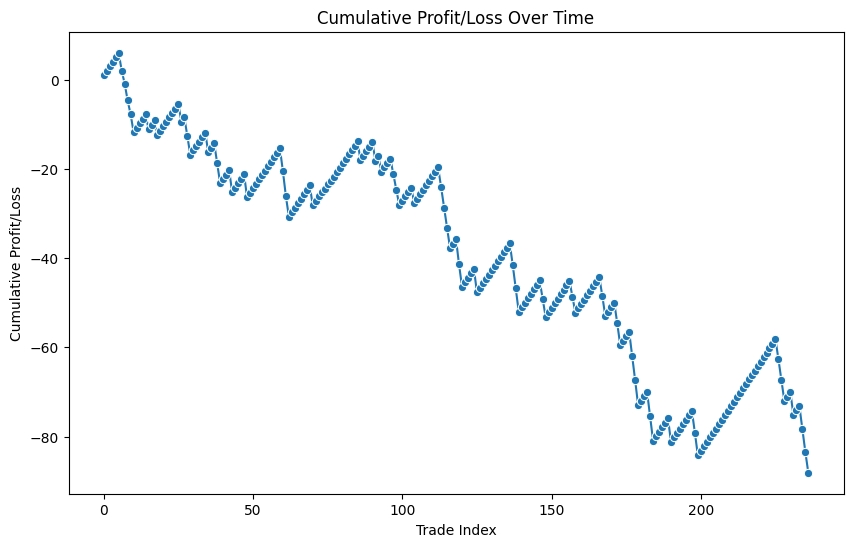

In [52]:
non_automated_trade_df['Cumulative_Profit_Loss'] = non_automated_trade_df['profit'].cumsum()
plt.figure(figsize=(10, 6))
sns.lineplot(x=non_automated_trade_df.index, y='Cumulative_Profit_Loss', data=non_automated_trade_df, marker='o')
plt.title('Cumulative Profit/Loss Over Time')
plt.xlabel('Trade Index')
plt.ylabel('Cumulative Profit/Loss')
plt.show()

In [51]:
non_automated_trade_df.head()

,ticket,order,time,time_msc,type,entry,magic,position_id,reason,volume,...,swap,profit,fee,symbol,comment,external_id,time_formatted,outcome,formatted_type,Cumulative_Profit_Loss
0,51990265279,52034582407,2025-01-21 13:42:23,1737466943208,1,1,234000,52034573946,5,0.1,...,0.0,1.0,0.0,EURUSD,[tp 1.03475],,2025-01-21 13:42:23,profit,sell,1.0
1,51990266808,52034583937,2025-01-21 13:42:41,1737466961730,1,1,234000,52034579726,5,0.1,...,0.0,1.0,0.0,EURUSD,[tp 1.03482],,2025-01-21 13:42:41,profit,sell,2.0
2,51990268219,52034585317,2025-01-21 13:42:57,1737466977555,1,1,234000,52034576501,5,0.1,...,0.0,1.0,0.0,EURUSD,[tp 1.03483],,2025-01-21 13:42:57,profit,sell,3.0
3,51990268220,52034585318,2025-01-21 13:42:57,1737466977557,1,1,234000,52034578379,5,0.1,...,0.0,1.0,0.0,EURUSD,[tp 1.03484],,2025-01-21 13:42:57,profit,sell,4.0
4,51990282723,52034599976,2025-01-21 13:47:03,1737467223935,0,1,234000,52034583526,5,0.1,...,0.0,1.0,0.0,EURUSD,[tp 1.03471],,2025-01-21 13:47:03,profit,buy,5.0


In [50]:
non_automated_trade_df.reset_index(drop=True, inplace=True)

In [30]:
import numpy as np

In [31]:
df= non_automated_trade_df

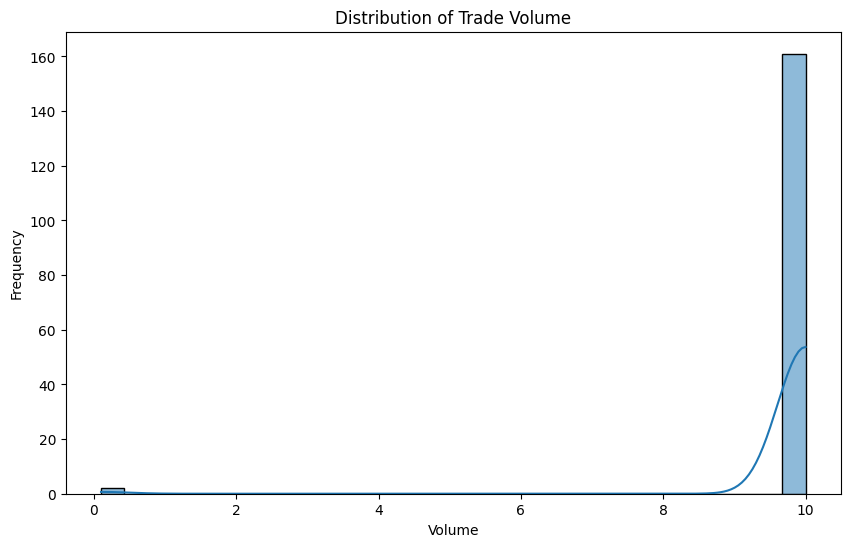

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(df['volume'], bins=30, kde=True)
plt.title('Distribution of Trade Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.show()


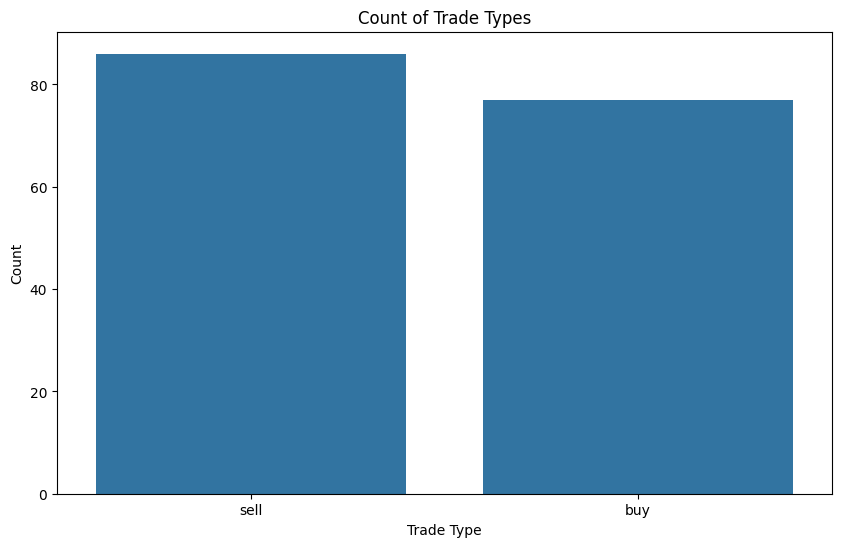

In [33]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='formatted_type')
plt.title('Count of Trade Types')
plt.xlabel('Trade Type')
plt.ylabel('Count')
plt.show()


In [34]:
df.head()

,ticket,order,time,time_msc,type,entry,magic,position_id,reason,volume,...,swap,profit,fee,symbol,comment,external_id,time_formatted,outcome,formatted_type,Cumulative_Profit_Loss
4,51907825263,51950098659,2024-12-24 09:31:46,1735032706300,1,1,234000,51950090030,4,10.0,...,0.0,-130.0,0.0,EURUSD,[sl 1.03962],,2024-12-24 09:31:46,loss,sell,-130.0
5,51907825264,51950098660,2024-12-24 09:31:46,1735032706301,1,1,234000,51950091080,4,10.0,...,0.0,-130.0,0.0,EURUSD,[sl 1.03963],,2024-12-24 09:31:46,loss,sell,-260.0
8,51907829943,51950103338,2024-12-24 09:34:25,1735032865862,1,1,234000,51950101667,4,10.0,...,0.0,-130.0,0.0,EURUSD,[sl 1.03960],,2024-12-24 09:34:25,loss,sell,-390.0
10,51907830596,51950103995,2024-12-24 09:34:52,1735032892872,1,1,234000,51950103763,4,10.0,...,0.0,-130.0,0.0,EURUSD,[sl 1.03961],,2024-12-24 09:34:52,loss,sell,-520.0
11,51907831499,51950104909,2024-12-24 09:35:26,1735032926100,1,1,234000,51950102204,4,10.0,...,0.0,-130.0,0.0,EURUSD,[sl 1.03958],,2024-12-24 09:35:26,loss,sell,-650.0


In [35]:
# Convert data types if needed
df['time'] = pd.to_datetime(df['time'])

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\2286703620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time'] = pd.to_datetime(df['time'])


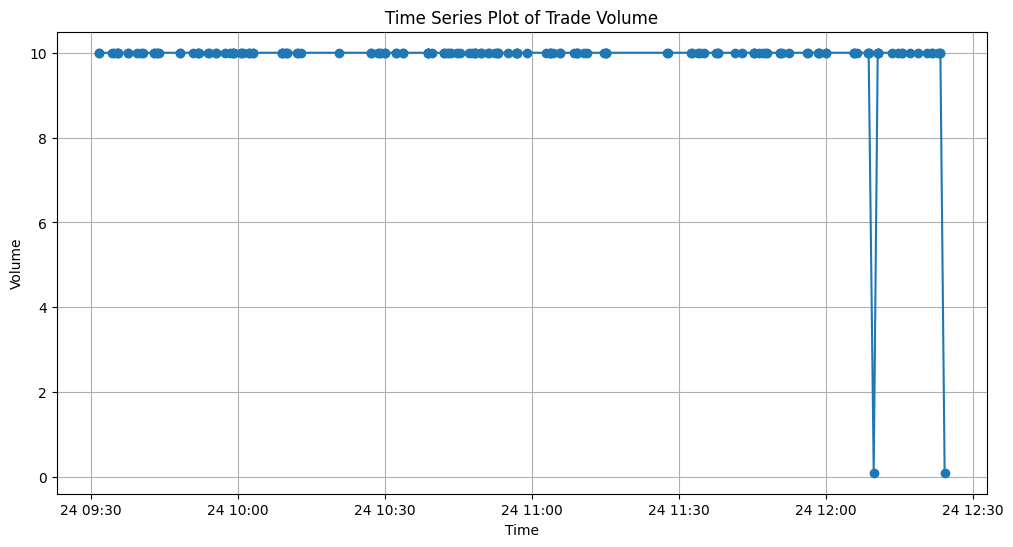

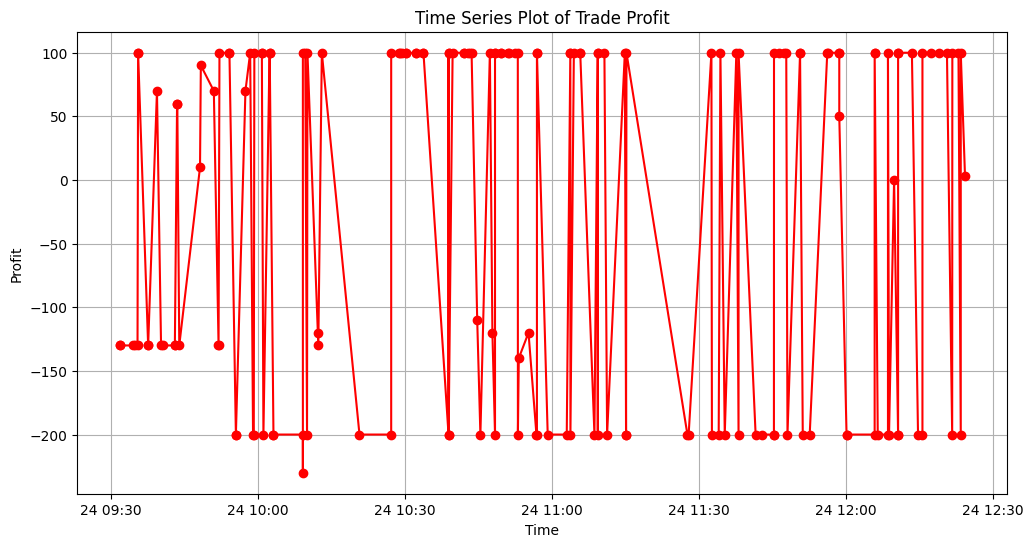

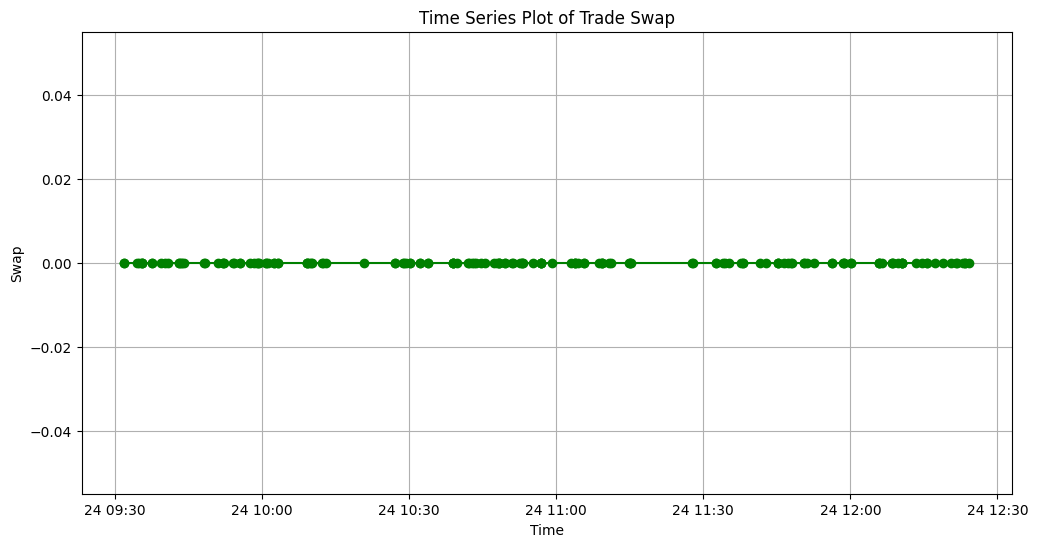

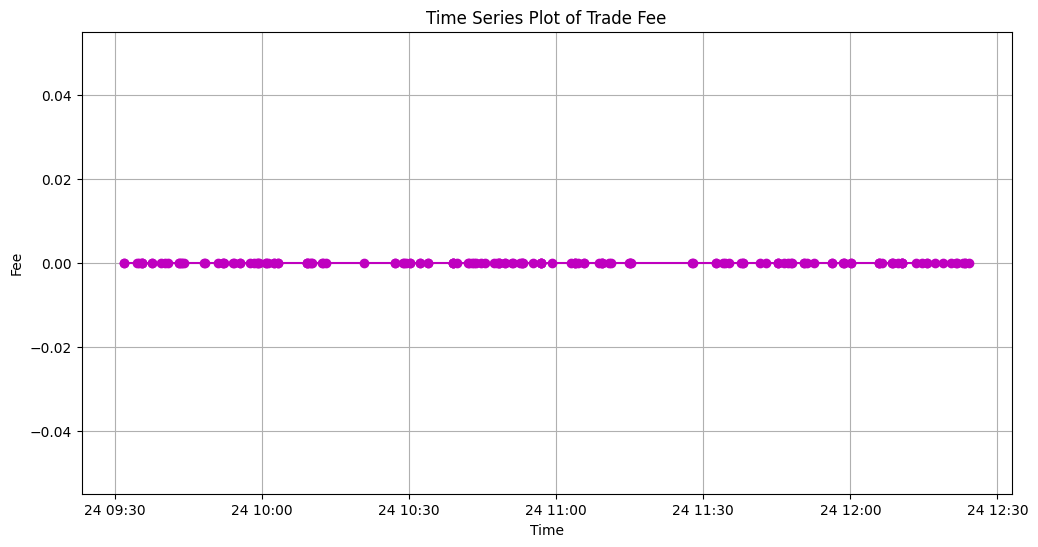

In [36]:
# Set 'time' as the index
df.set_index('time', inplace=True)

# Plot the time series for 'volume'
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['volume'], marker='o', linestyle='-')
plt.xlabel('Time')
plt.ylabel('Volume')
plt.title('Time Series Plot of Trade Volume')
plt.grid(True)
plt.show()

# Plot the time series for 'profit'
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['profit'], marker='o', linestyle='-', color='r')
plt.xlabel('Time')
plt.ylabel('Profit')
plt.title('Time Series Plot of Trade Profit')
plt.grid(True)
plt.show()

# Plot the time series for 'swap'
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['swap'], marker='o', linestyle='-', color='g')
plt.xlabel('Time')
plt.ylabel('Swap')
plt.title('Time Series Plot of Trade Swap')
plt.grid(True)
plt.show()

# Plot the time series for 'fee'
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['fee'], marker='o', linestyle='-', color='m')
plt.xlabel('Time')
plt.ylabel('Fee')
plt.title('Time Series Plot of Trade Fee')
plt.grid(True)
plt.show()

In [37]:
# Summary statistics for numerical columns
df.describe()

,ticket,order,time_msc,type,entry,magic,position_id,reason,volume,price,commission,swap,profit,fee,time_formatted,Cumulative_Profit_Loss
count,1.630000e+02,1.630000e+02,1.630000e+02,163.000000,163.000000,163.000000,1.630000e+02,163.000000,163.000000,163.000000,163.0,163.0,163.000000,163.0,163,163.000000
mean,5.190804e+10,5.195031e+10,1.735038e+12,0.527607,0.993865,212466.257669,5.195030e+10,4.233129,9.878528,1.039504,0.0,0.0,-27.036196,0.0,2024-12-24 10:56:22.938650368,-2248.569939
min,5.190783e+10,5.195010e+10,1.735033e+12,0.000000,0.000000,0.000000,5.195009e+10,0.000000,0.100000,1.038950,0.0,0.0,-230.000000,0.0,2024-12-24 09:31:46,-4710.000000
25%,5.190792e+10,5.195019e+10,1.735035e+12,0.000000,1.000000,234000.000000,5.195018e+10,4.000000,10.000000,1.039290,0.0,0.0,-200.000000,0.0,2024-12-24 10:09:10,-3360.000000
50%,5.190802e+10,5.195029e+10,1.735038e+12,1.000000,1.000000,234000.000000,5.195029e+10,5.000000,10.000000,1.039430,0.0,0.0,90.000000,0.0,2024-12-24 10:52:32,-1860.000000
75%,5.190817e+10,5.195044e+10,1.735041e+12,1.000000,1.000000,234000.000000,5.195043e+10,5.000000,10.000000,1.039625,0.0,0.0,100.000000,0.0,2024-12-24 11:45:16.500000,-1360.000000
max,5.190828e+10,5.195055e+10,1.735043e+12,1.000000,1.000000,234000.000000,5.195055e+10,5.000000,10.000000,1.040520,0.0,0.0,100.000000,0.0,2024-12-24 12:24:15,-130.000000
std,1.378338e+05,1.386116e+05,3.139011e+06,0.500776,0.078326,67848.622557,1.373215e+05,1.130774,1.093231,0.000331,0.0,0.0,139.327392,0.0,NaN,1197.830818


In [38]:

# Summary statistics for categorical columns
df.describe(include=['object'])

,symbol,comment,external_id,outcome,formatted_type
count,163,163,163,163,163
unique,1,105,1,3,2
top,EURUSD,,,profit,sell
freq,163,15,163,90,86


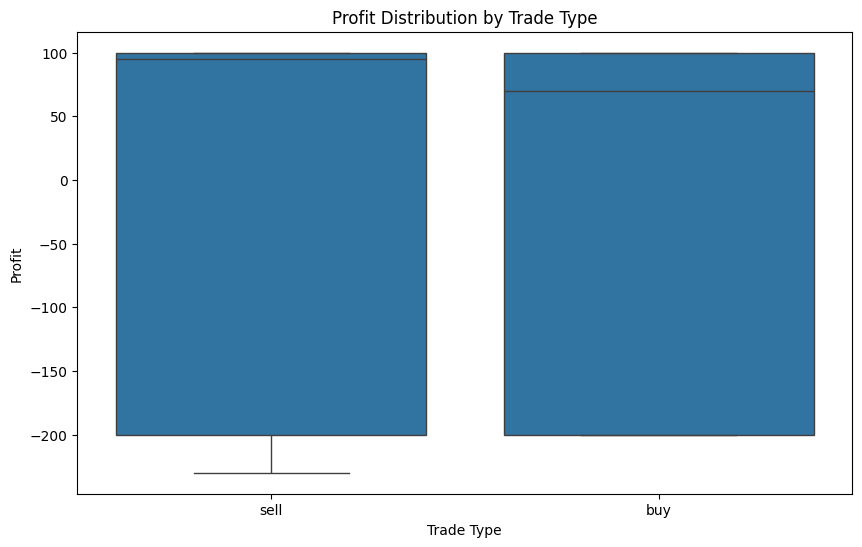

In [39]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='formatted_type', y='profit')
plt.title('Profit Distribution by Trade Type')
plt.xlabel('Trade Type')
plt.ylabel('Profit')
plt.show()


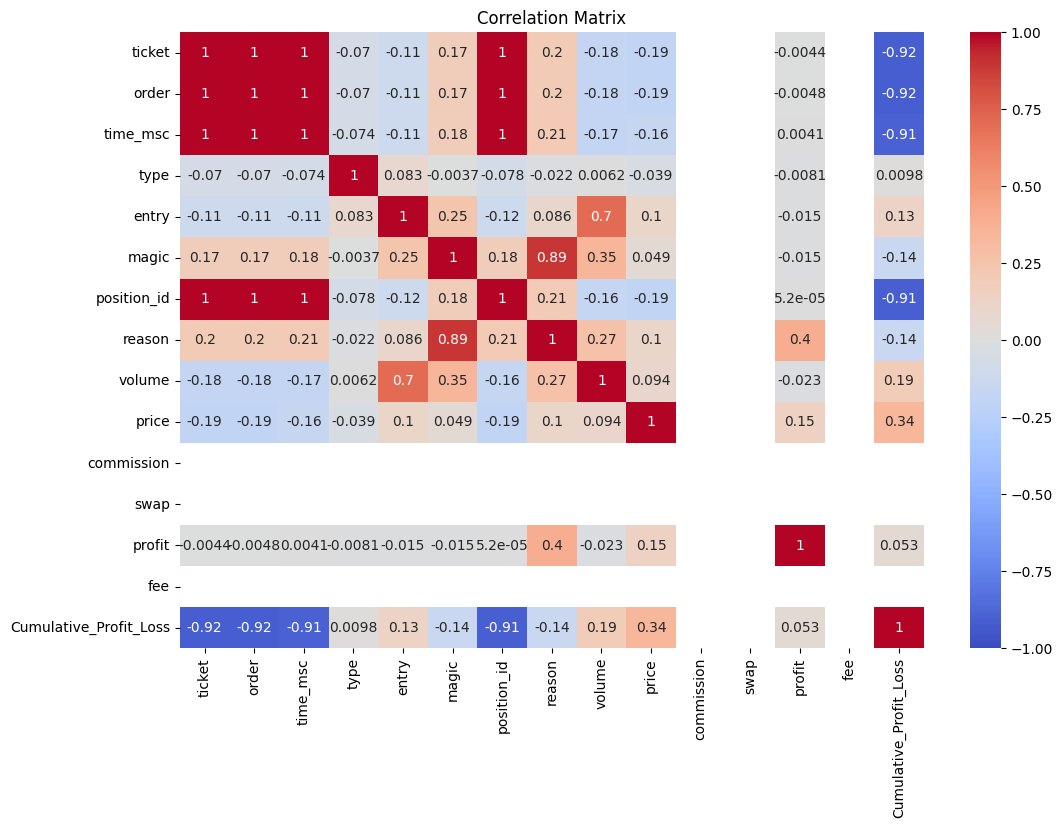

In [40]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

In [41]:
# Select only the numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Add the 'formatted_type' column to the numeric DataFrame
numeric_df = df[['formatted_type']].join(numeric_df)

# Group by 'formatted_type' and calculate the mean
trade_type_summary = numeric_df.groupby('formatted_type').mean()
trade_type_summary


,ticket,order,time_msc,type,entry,magic,position_id,reason,volume,price,commission,swap,profit,fee,Cumulative_Profit_Loss
formatted_type,,,,,,,,,,,,,,,
buy,5.190806e+10,5.195033e+10,1.735038e+12,0.173913,0.991304,219756.521739,5.195033e+10,4.356522,9.913913,1.039497,0.0,0.0,-29.304348,0.0,-2406.000000
sell,5.190804e+10,5.195031e+10,1.735038e+12,0.848485,1.000000,219818.181818,5.195030e+10,4.310606,9.925000,1.039489,0.0,0.0,-32.779545,0.0,-2338.840152


outcome
profit            90
loss              72
no profit/loss     1
Name: count, dtype: int64


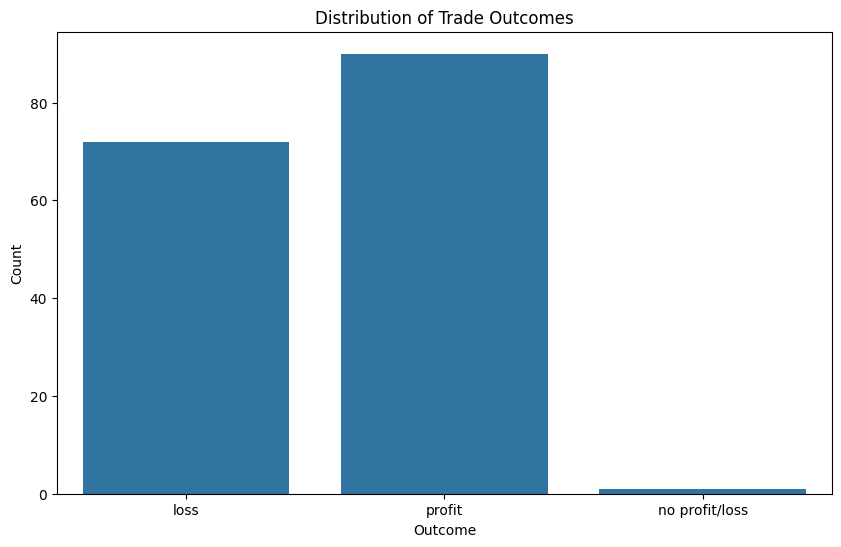

In [42]:
# Count of outcomes
outcome_count = df['outcome'].value_counts()
print(outcome_count)

# Visualize the outcome distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='outcome')
plt.title('Distribution of Trade Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()


In [43]:
df.head()

,ticket,order,time_msc,type,entry,magic,position_id,reason,volume,price,...,swap,profit,fee,symbol,comment,external_id,time_formatted,outcome,formatted_type,Cumulative_Profit_Loss
time,,,,,,,,,,,,,,,,,,,,,
2024-12-24 09:31:46,51907825263,51950098659,1735032706300,1,1,234000,51950090030,4,10.0,1.03962,...,0.0,-130.0,0.0,EURUSD,[sl 1.03962],,2024-12-24 09:31:46,loss,sell,-130.0
2024-12-24 09:31:46,51907825264,51950098660,1735032706301,1,1,234000,51950091080,4,10.0,1.03963,...,0.0,-130.0,0.0,EURUSD,[sl 1.03963],,2024-12-24 09:31:46,loss,sell,-260.0
2024-12-24 09:34:25,51907829943,51950103338,1735032865862,1,1,234000,51950101667,4,10.0,1.03960,...,0.0,-130.0,0.0,EURUSD,[sl 1.03960],,2024-12-24 09:34:25,loss,sell,-390.0
2024-12-24 09:34:52,51907830596,51950103995,1735032892872,1,1,234000,51950103763,4,10.0,1.03961,...,0.0,-130.0,0.0,EURUSD,[sl 1.03961],,2024-12-24 09:34:52,loss,sell,-520.0
2024-12-24 09:35:26,51907831499,51950104909,1735032926100,1,1,234000,51950102204,4,10.0,1.03958,...,0.0,-130.0,0.0,EURUSD,[sl 1.03958],,2024-12-24 09:35:26,loss,sell,-650.0


In [68]:
plt.figure(figsize=(12, 6))
df['Cumulative_Profit_Loss'] = df['profit'].cumsum()
df.plot(x='time', y='Cumulative_Profit_Loss', figsize=(12, 6))
plt.title('Cumulative Profit/Loss Over Time')
plt.xlabel('Time')
plt.ylabel('Cumulative Profit/Loss')
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\2851996042.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cumulative_Profit_Loss'] = df['profit'].cumsum()


KeyError: 'time'

<Figure size 1200x600 with 0 Axes>

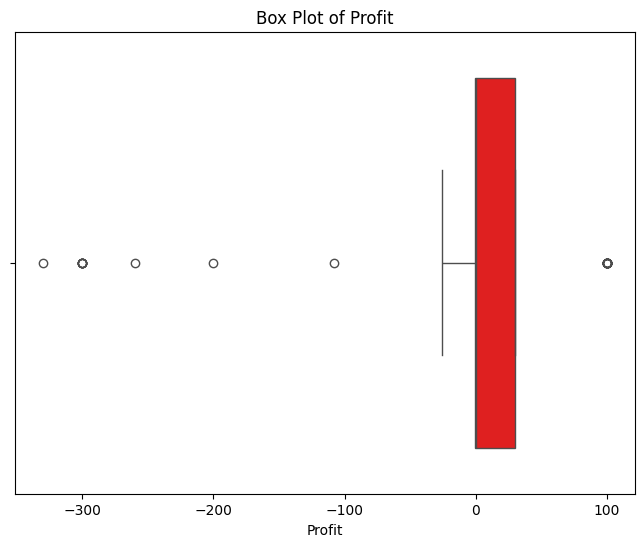

In [57]:
# Box plot for 'profit'
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['profit'], color='red')
plt.title('Box Plot of Profit')
plt.xlabel('Profit')
plt.show()

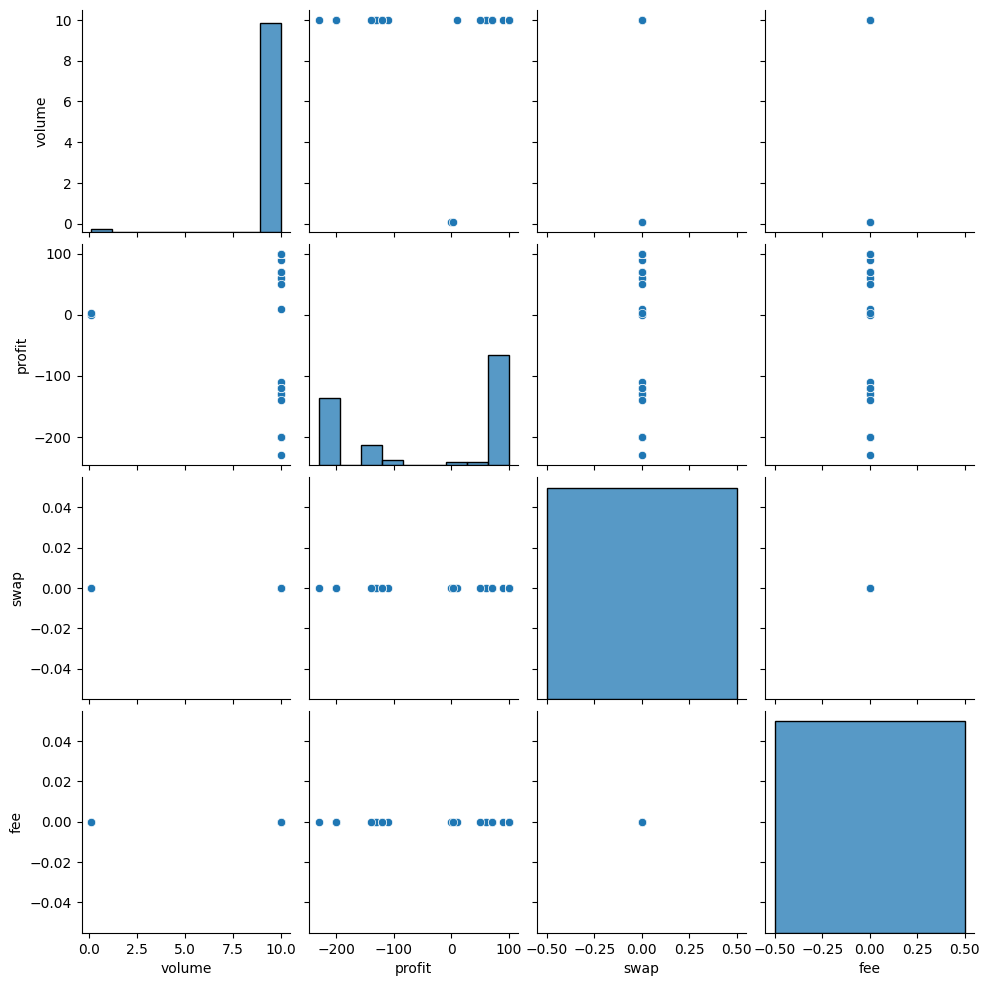

In [45]:
# Pair plot
sns.pairplot(df[['volume', 'profit', 'swap', 'fee']])
plt.show()


formatted_type        buy       sell
symbol                              
EURUSD         -25.844156 -28.103488


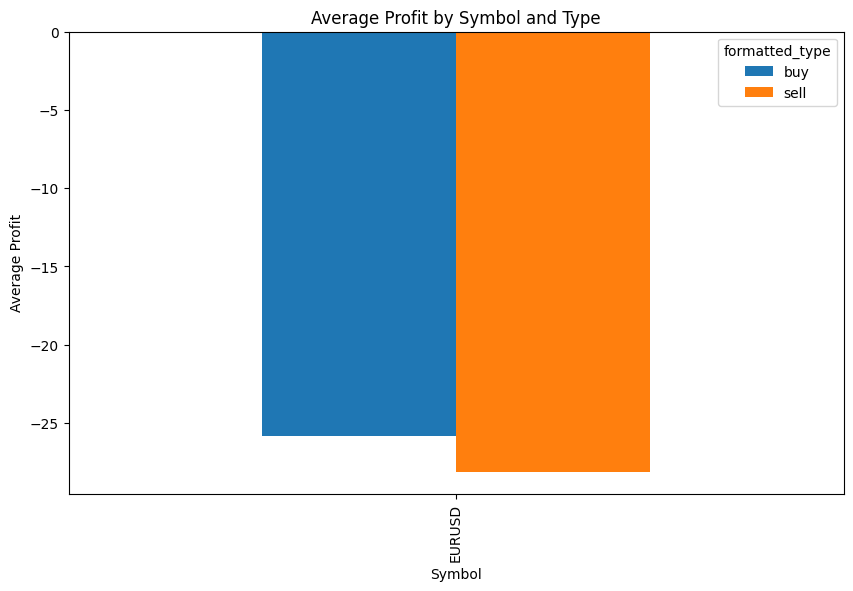

In [46]:
# Pivot table for 'profit' by 'symbol' and 'formatted_type'
pivot_table = df.pivot_table(values='profit', index='symbol', columns='formatted_type', aggfunc='mean')
print(pivot_table)

# Plotting the pivot table
pivot_table.plot(kind='bar', figsize=(10, 6))
plt.title('Average Profit by Symbol and Type')
plt.xlabel('Symbol')
plt.ylabel('Average Profit')
plt.show()


c:\Users\ADMIN\miniconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


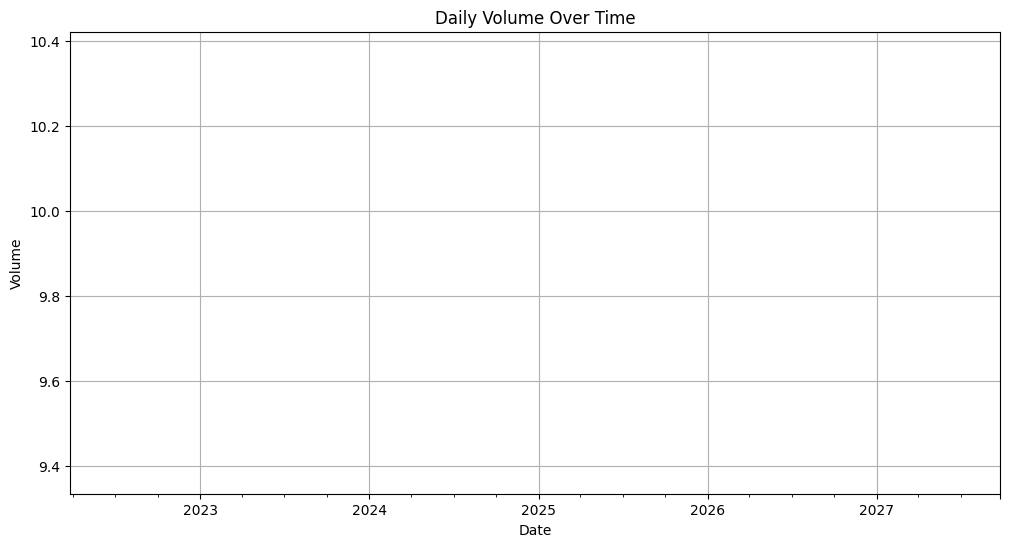

In [47]:
# Resample the data by day and get the mean of 'volume'
daily_volume = df['volume'].resample('D').mean()

# Plotting the daily volume
plt.figure(figsize=(12, 6))
daily_volume.plot()
plt.title('Daily Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\1434482583.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df.resample('H').agg({


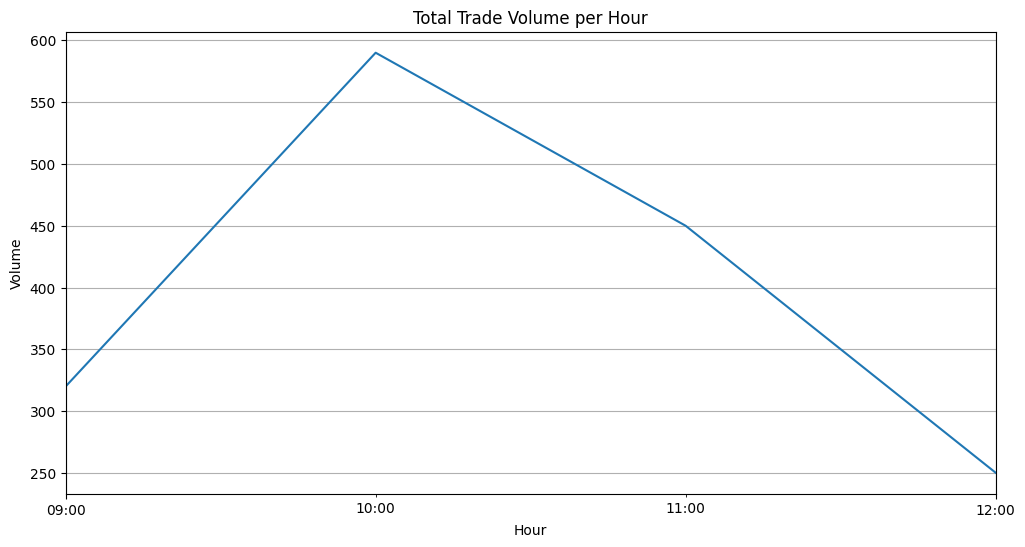

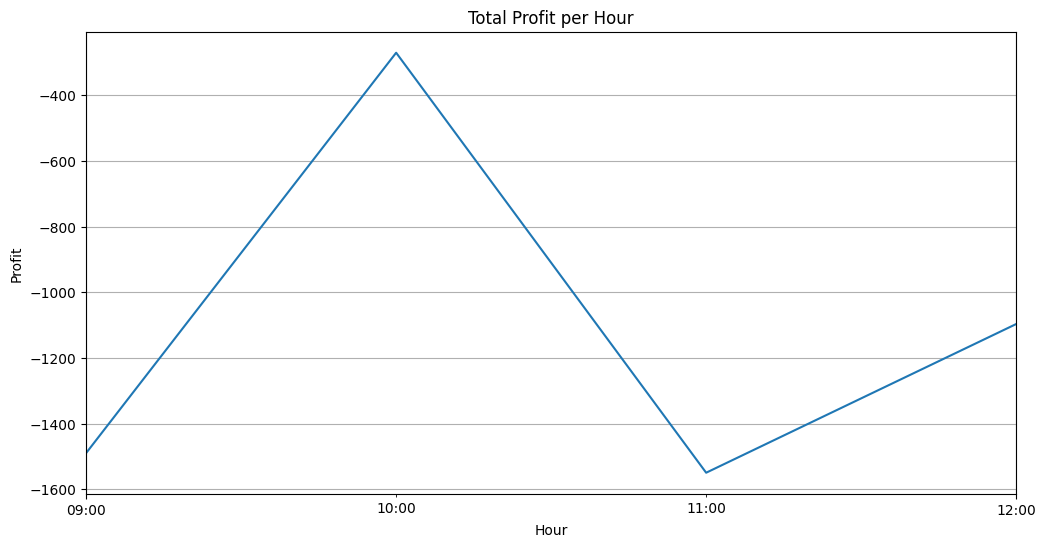

In [48]:
# Resample data to hourly intervals, taking the sum of volume, profit, and number of trades
df_resampled = df.resample('H').agg({
    'volume': 'sum',        # Sum of volume traded in the hour
    'profit': 'sum',        # Sum of profit made in the hour
    'swap': 'sum',          # Sum of swap in the hour
    'fee': 'sum',           # Sum of fees in the hour
    'order': 'count'        # Count number of trades in the hour
})

# Plot hourly trade volume
plt.figure(figsize=(12, 6))
df_resampled['volume'].plot()
plt.title('Total Trade Volume per Hour')
plt.xlabel('Hour')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

# Plot hourly profit
plt.figure(figsize=(12, 6))
df_resampled['profit'].plot()
plt.title('Total Profit per Hour')
plt.xlabel('Hour')
plt.ylabel('Profit')
plt.grid(True)
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\2145216110.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df.index.hour


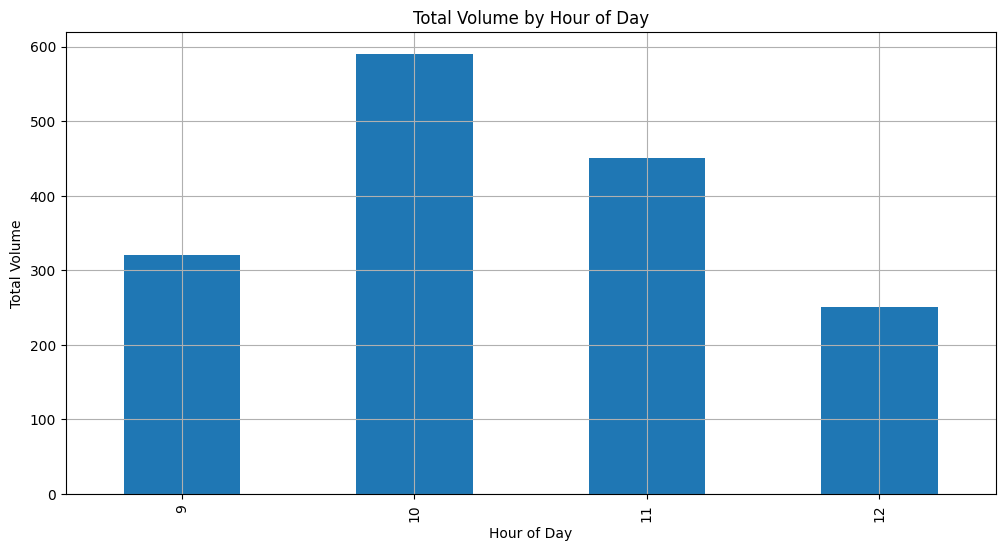

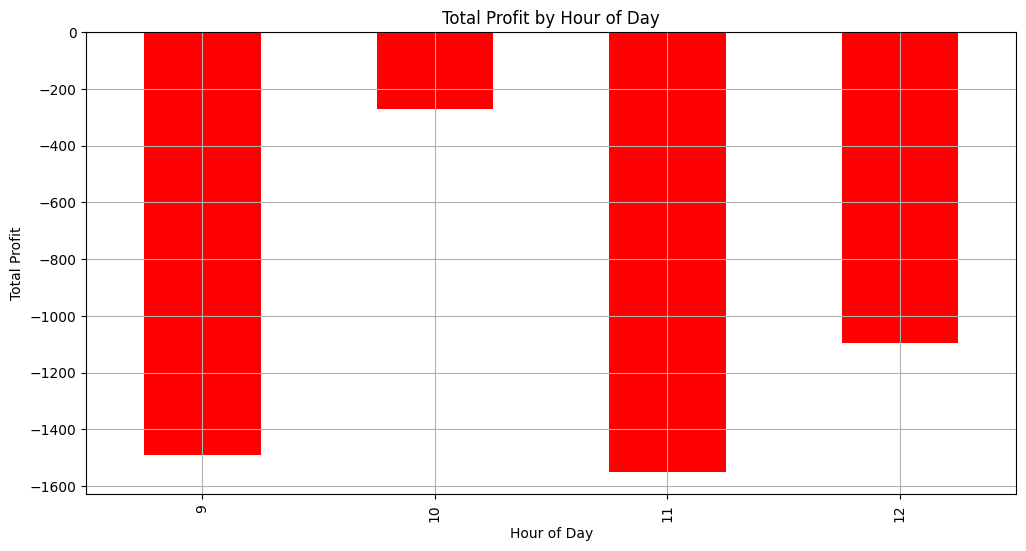

In [49]:
# Extract hour from the time column
df['hour'] = df.index.hour

# Group by hour and get the sum of volume, profit, etc.
hourly_stats = df.groupby('hour').agg({
    'volume': 'sum',
    'profit': 'sum',
    'swap': 'sum',
    'fee': 'sum',
    'order': 'count'
})

# Plot the sum of volume by hour
plt.figure(figsize=(12, 6))
hourly_stats['volume'].plot(kind='bar')
plt.title('Total Volume by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Volume')
plt.grid(True)
plt.show()

# Plot the sum of profit by hour
plt.figure(figsize=(12, 6))
hourly_stats['profit'].plot(kind='bar', color='red')
plt.title('Total Profit by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Profit')
plt.grid(True)
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\1534670458.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df['volume_rolling_avg'] = df['volume'].rolling('30T').mean()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\1534670458.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['volume_rolling_avg'] = df['volume'].rolling('30T').mean()


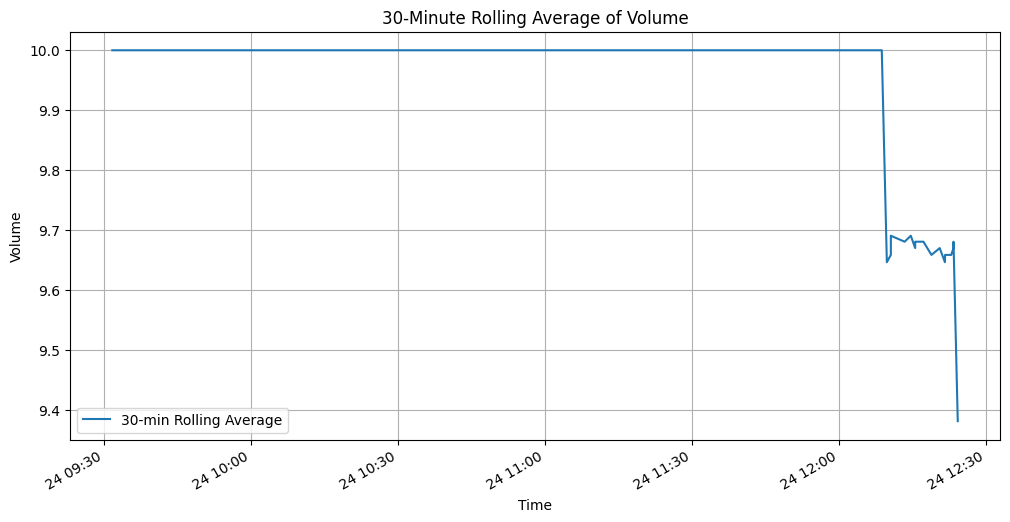

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\1534670458.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df['profit_rolling_avg'] = df['profit'].rolling('30T').mean()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\1534670458.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['profit_rolling_avg'] = df['profit'].rolling('30T').mean()


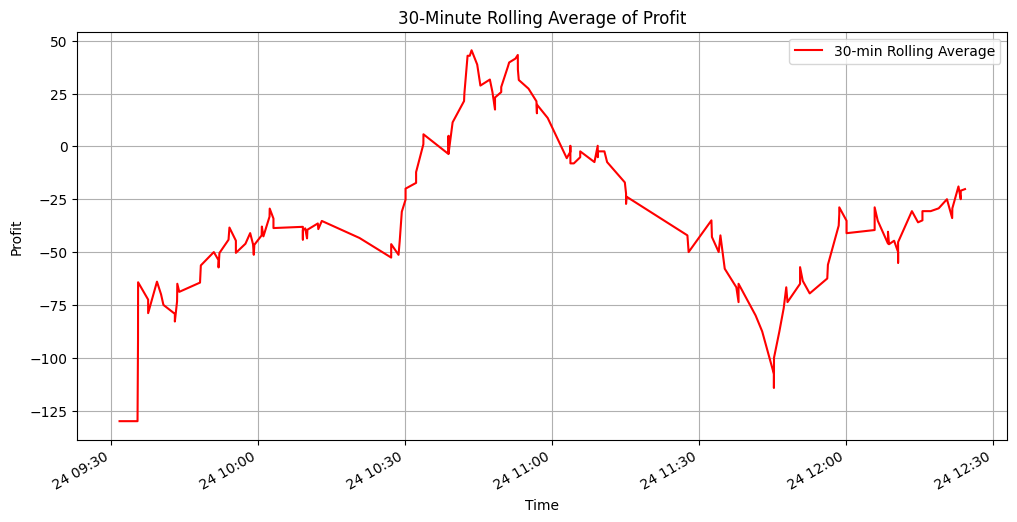

In [50]:
# Rolling average of volume (e.g., over 30 minutes window)
df['volume_rolling_avg'] = df['volume'].rolling('30T').mean()

# Plot the rolling average of volume
plt.figure(figsize=(12, 6))
df['volume_rolling_avg'].plot(label='30-min Rolling Average')
plt.title('30-Minute Rolling Average of Volume')
plt.xlabel('Time')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.show()

# Rolling average of profit
df['profit_rolling_avg'] = df['profit'].rolling('30T').mean()

# Plot the rolling average of profit
plt.figure(figsize=(12, 6))
df['profit_rolling_avg'].plot(label='30-min Rolling Average', color='red')
plt.title('30-Minute Rolling Average of Profit')
plt.xlabel('Time')
plt.ylabel('Profit')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\774883696.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cumulative_volume'] = df['volume'].cumsum()


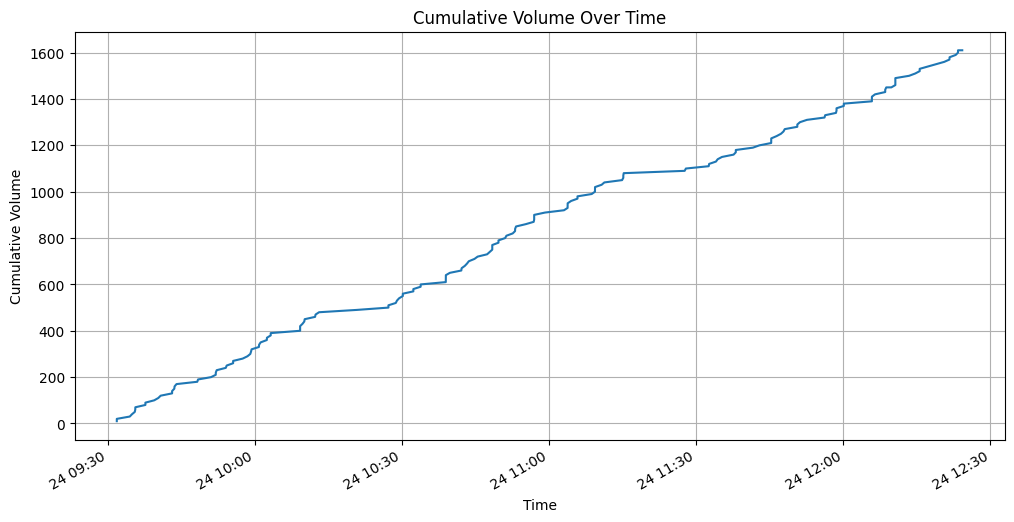

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\774883696.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cumulative_profit'] = df['profit'].cumsum()


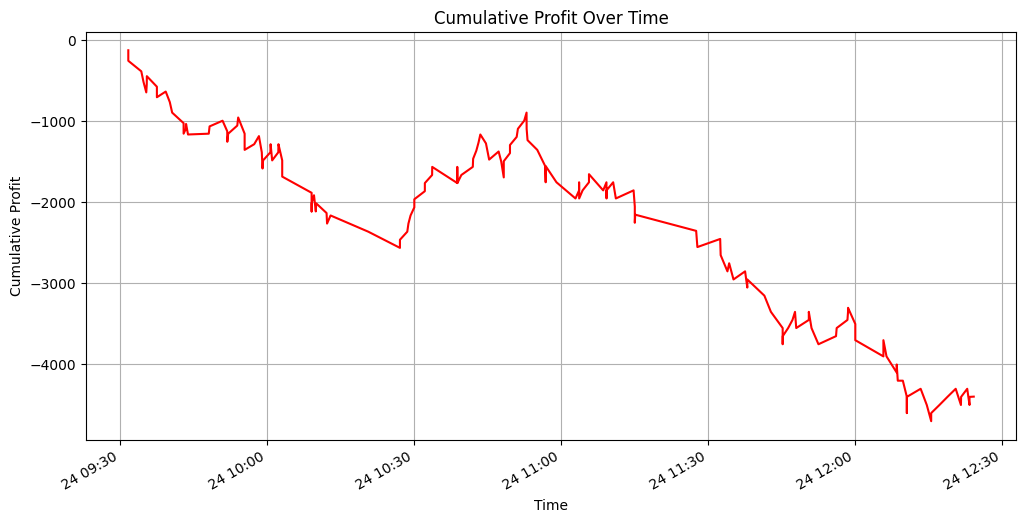

In [51]:
# Cumulative sum of volume
df['cumulative_volume'] = df['volume'].cumsum()

# Plot cumulative volume over time
plt.figure(figsize=(12, 6))
df['cumulative_volume'].plot()
plt.title('Cumulative Volume Over Time')
plt.xlabel('Time')
plt.ylabel('Cumulative Volume')
plt.grid(True)
plt.show()

# Cumulative sum of profit
df['cumulative_profit'] = df['profit'].cumsum()

# Plot cumulative profit over time
plt.figure(figsize=(12, 6))
df['cumulative_profit'].plot(color='red')
plt.title('Cumulative Profit Over Time')
plt.xlabel('Time')
plt.ylabel('Cumulative Profit')
plt.grid(True)
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\2947394258.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled_trades = df.resample('10T').count()


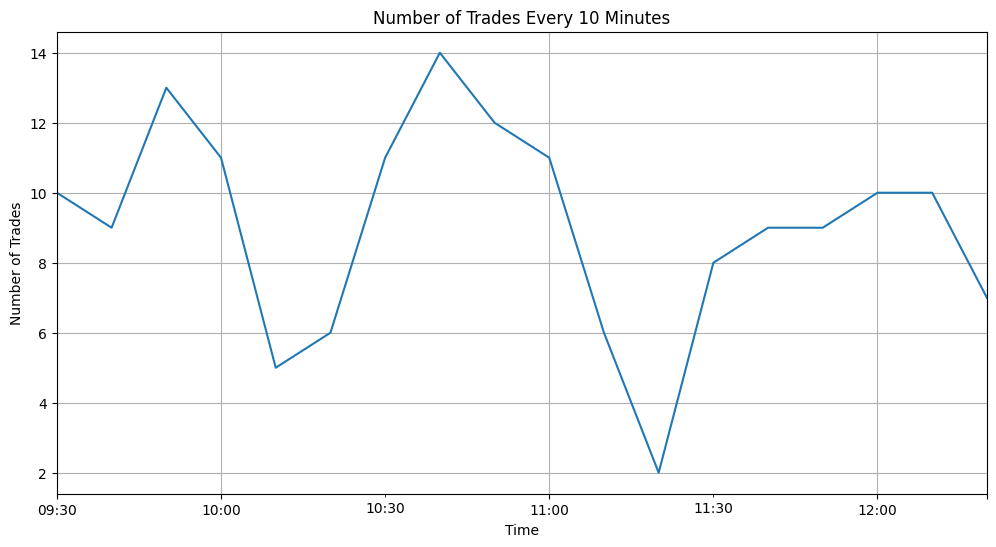

In [52]:
# Resample the data to count trades in 10-minute intervals
df_resampled_trades = df.resample('10T').count()

# Plot the number of trades per 10 minutes
plt.figure(figsize=(12, 6))
df_resampled_trades['order'].plot()
plt.title('Number of Trades Every 10 Minutes')
plt.xlabel('Time')
plt.ylabel('Number of Trades')
plt.grid(True)
plt.show()


<Figure size 2400x1600 with 0 Axes>

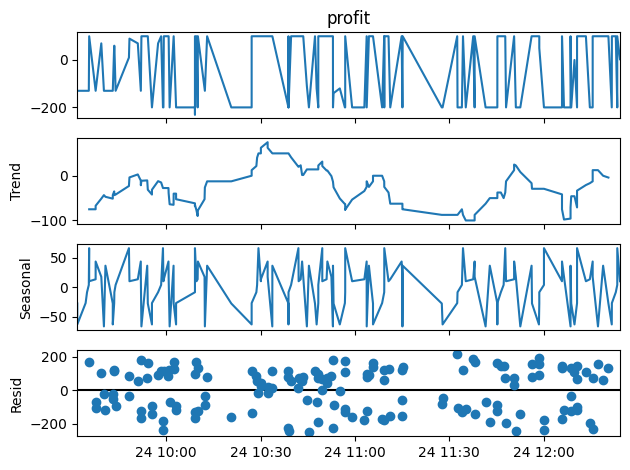

In [53]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming df is set to datetime index and contains numerical values like 'volume' or 'profit'
decomposition = seasonal_decompose(df['profit'], model='additive', period=12)  # 'period' can be adjusted

# Plot the decomposition
plt.figure(figsize=(24, 16))
decomposition.plot()
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\3284084215.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time_diff'] = df.index.diff().fillna(pd.Timedelta(seconds=0))


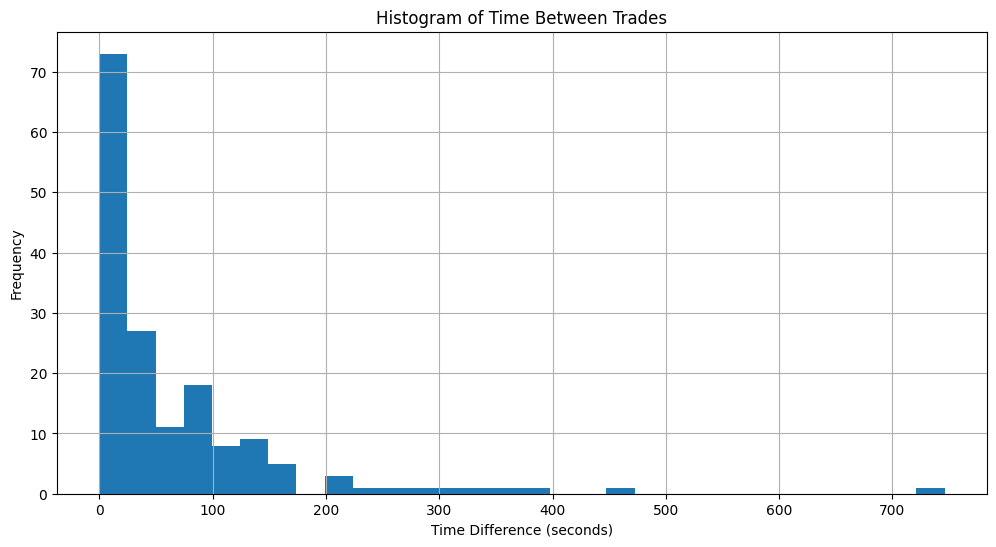

In [54]:
# Calculate time difference between consecutive trades
df['time_diff'] = df.index.diff().fillna(pd.Timedelta(seconds=0))

# Plot histogram of time differences between trades
plt.figure(figsize=(12, 6))
df['time_diff'].dt.total_seconds().plot(kind='hist', bins=30)
plt.title('Histogram of Time Between Trades')
plt.xlabel('Time Difference (seconds)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\2319585501.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rolling_mean'] = df['profit'].rolling(window=30, min_periods=1).mean()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\2319585501.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rolling_std'] = df['profit'].rolling(window=30, min_periods=1).std()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\2319585501.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

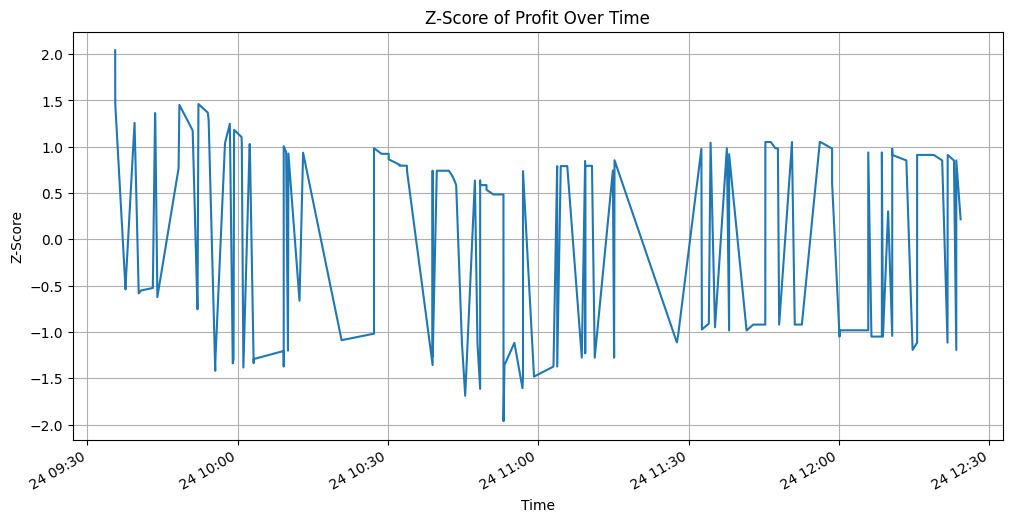

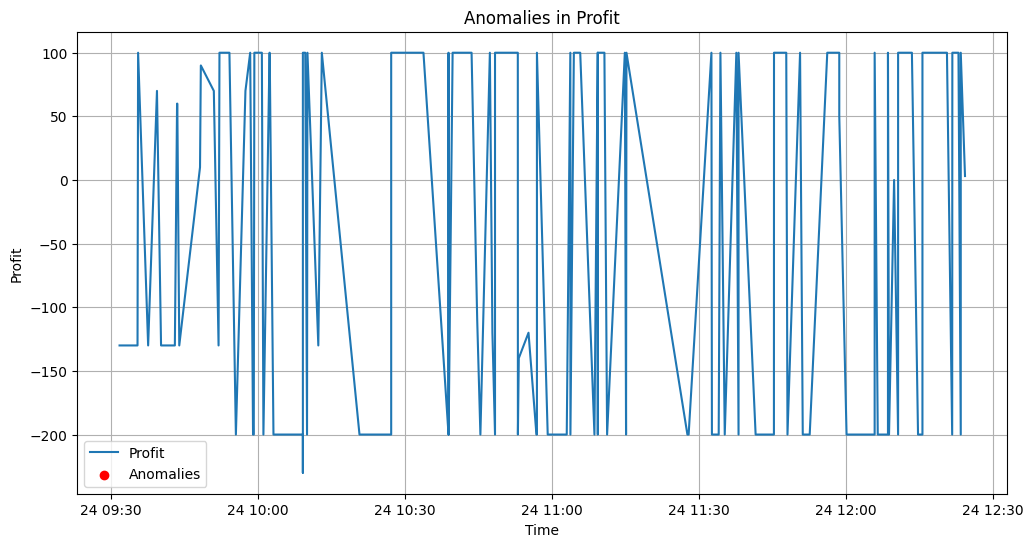

In [55]:
# Calculate rolling mean and standard deviation
df['rolling_mean'] = df['profit'].rolling(window=30, min_periods=1).mean()
df['rolling_std'] = df['profit'].rolling(window=30, min_periods=1).std()

# Calculate z-scores
df['z_score'] = (df['profit'] - df['rolling_mean']) / df['rolling_std']

# Plot z-scores
plt.figure(figsize=(12, 6))
df['z_score'].plot()
plt.title('Z-Score of Profit Over Time')
plt.xlabel('Time')
plt.ylabel('Z-Score')
plt.grid(True)
plt.show()

# Mark anomalies based on a threshold, e.g., z-score > 3
anomalies = df[df['z_score'].abs() > 3]
plt.figure(figsize=(12, 6))
plt.plot(df['profit'], label='Profit')
plt.scatter(anomalies.index, anomalies['profit'], color='red', label='Anomalies')
plt.title('Anomalies in Profit')
plt.xlabel('Time')
plt.ylabel('Profit')
plt.legend()
plt.grid(True)
plt.show()


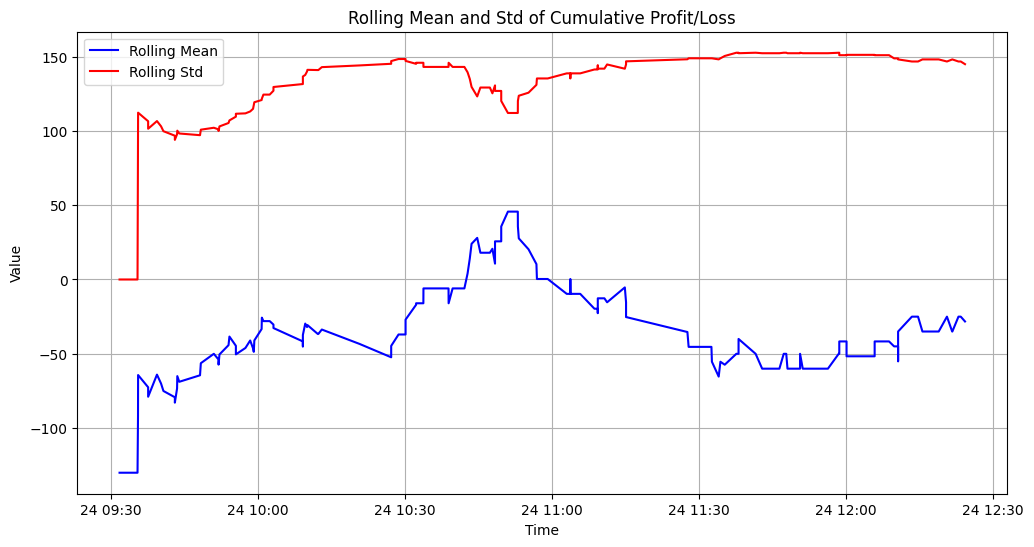

In [56]:
# Plot rolling mean and rolling standard deviation of cumulative profit
plt.figure(figsize=(12, 6))
plt.plot(df['rolling_mean'], label='Rolling Mean', color='blue')
plt.plot(df['rolling_std'], label='Rolling Std', color='red')
plt.title('Rolling Mean and Std of Cumulative Profit/Loss')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


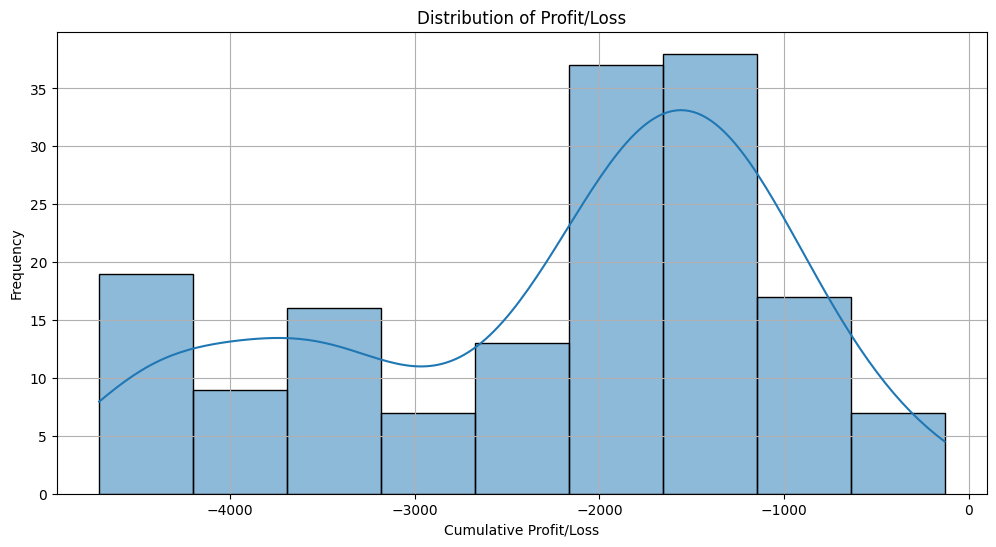

In [57]:
# Plot the distribution of profit/loss
plt.figure(figsize=(12, 6))
sns.histplot(df['Cumulative_Profit_Loss'], kde=True)
plt.title('Distribution of Profit/Loss')
plt.xlabel('Cumulative Profit/Loss')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6604\2227361854.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trade_duration'] = df['time_diff'].dt.total_seconds() / 60  # Convert to minutes


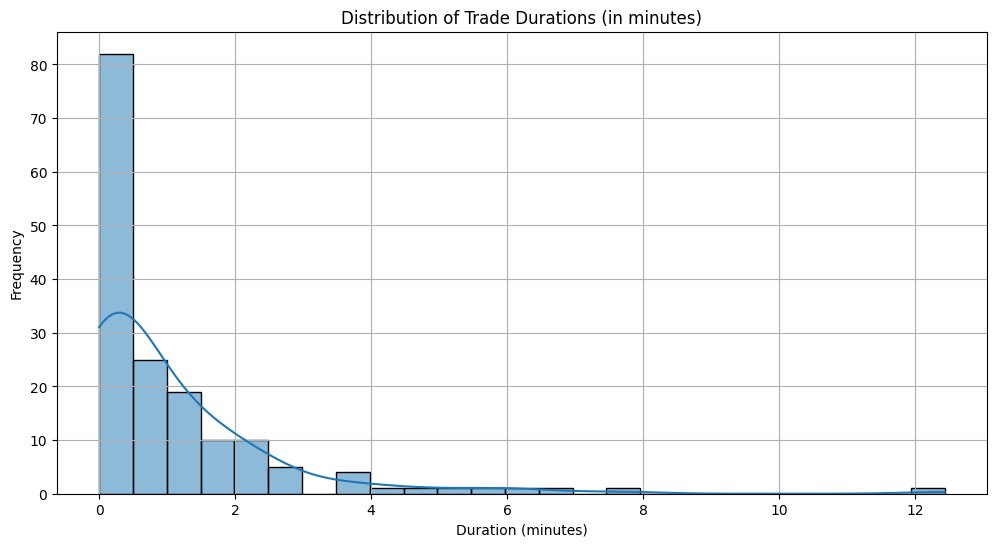

In [58]:
# Plot distribution of trade durations
df['trade_duration'] = df['time_diff'].dt.total_seconds() / 60  # Convert to minutes

plt.figure(figsize=(12, 6))
sns.histplot(df['trade_duration'], kde=True)
plt.title('Distribution of Trade Durations (in minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


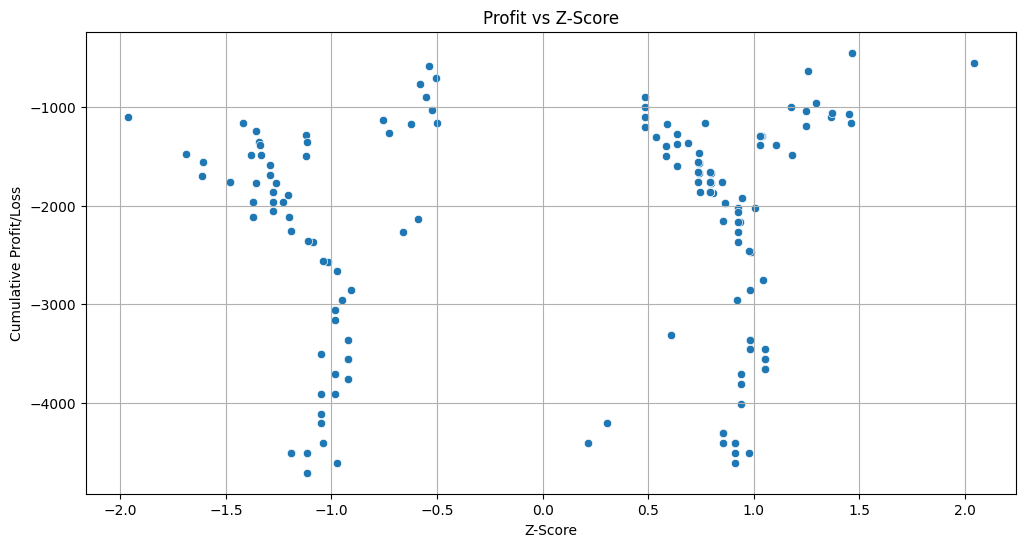

In [59]:
# Reset index to avoid duplicate index issues
df_reset = df.reset_index(drop=True)

# Plot profit vs Z-Score
plt.figure(figsize=(12, 6))
sns.scatterplot(x='z_score', y='Cumulative_Profit_Loss', data=df_reset)
plt.title('Profit vs Z-Score')
plt.xlabel('Z-Score')
plt.ylabel('Cumulative Profit/Loss')
plt.grid(True)
plt.show()


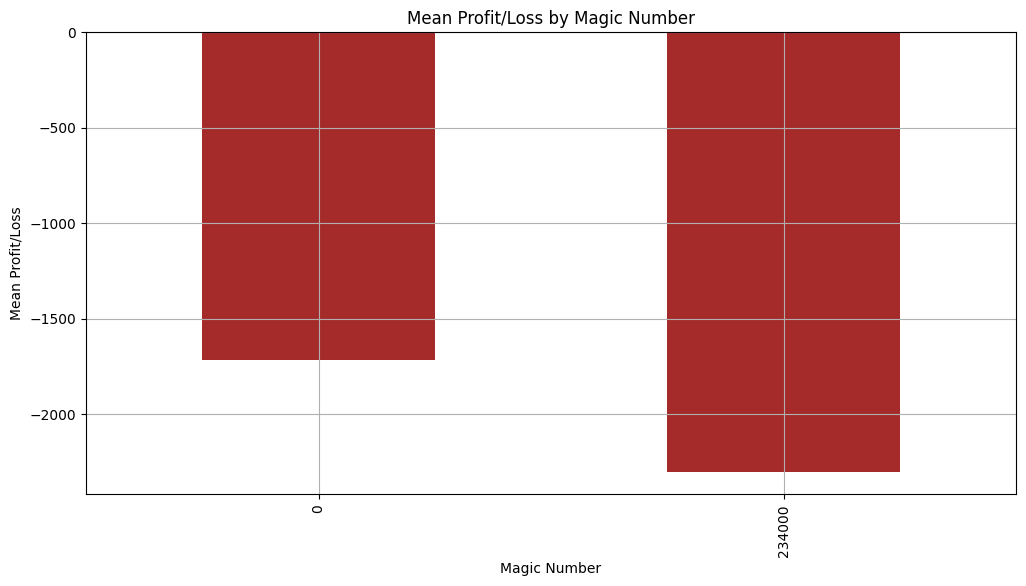

In [60]:
# Analyze profit by magic number
magic_performance = df.groupby('magic')['Cumulative_Profit_Loss'].agg(['mean', 'sum'])

# Plot profit by magic number
magic_performance['mean'].plot(kind='bar', color='brown', figsize=(12, 6))
plt.title('Mean Profit/Loss by Magic Number')
plt.xlabel('Magic Number')
plt.ylabel('Mean Profit/Loss')
plt.grid(True)
plt.show()


In [61]:
df.head()

,ticket,order,time_msc,type,entry,magic,position_id,reason,volume,price,...,hour,volume_rolling_avg,profit_rolling_avg,cumulative_volume,cumulative_profit,time_diff,rolling_mean,rolling_std,z_score,trade_duration
time,,,,,,,,,,,,,,,,,,,,,
2024-12-24 09:31:46,51907825263,51950098659,1735032706300,1,1,234000,51950090030,4,10.0,1.03962,...,9,10.0,-130.0,10.0,-130.0,0 days 00:00:00,-130.0,NaN,NaN,0.000000
2024-12-24 09:31:46,51907825264,51950098660,1735032706301,1,1,234000,51950091080,4,10.0,1.03963,...,9,10.0,-130.0,20.0,-260.0,0 days 00:00:00,-130.0,0.0,NaN,0.000000
2024-12-24 09:34:25,51907829943,51950103338,1735032865862,1,1,234000,51950101667,4,10.0,1.03960,...,9,10.0,-130.0,30.0,-390.0,0 days 00:02:39,-130.0,0.0,NaN,2.650000
2024-12-24 09:34:52,51907830596,51950103995,1735032892872,1,1,234000,51950103763,4,10.0,1.03961,...,9,10.0,-130.0,40.0,-520.0,0 days 00:00:27,-130.0,0.0,NaN,0.450000
2024-12-24 09:35:26,51907831499,51950104909,1735032926100,1,1,234000,51950102204,4,10.0,1.03958,...,9,10.0,-130.0,50.0,-650.0,0 days 00:00:34,-130.0,0.0,NaN,0.566667


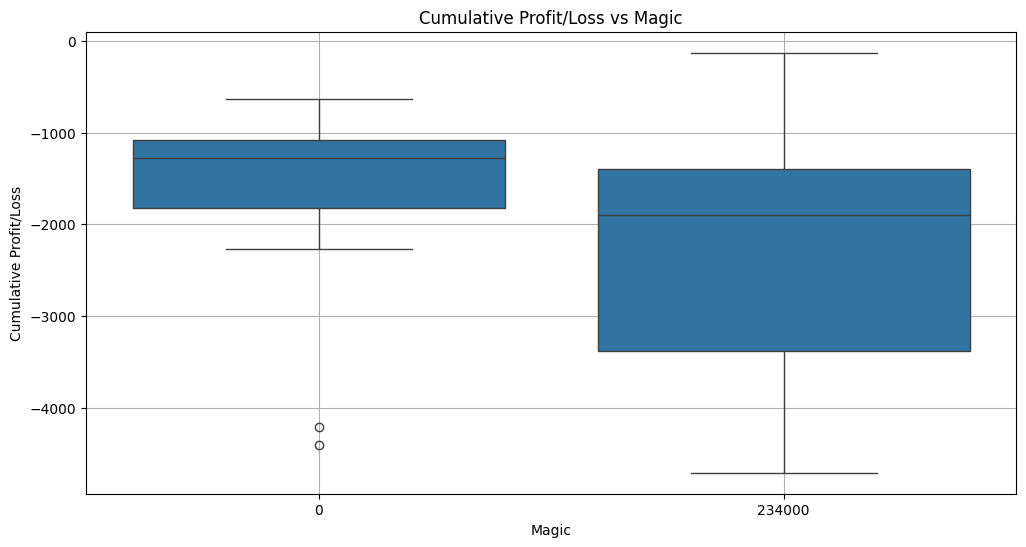

In [62]:
# Boxplot for comparing Cumulative Profit/Loss across different magic values
plt.figure(figsize=(12, 6))
sns.boxplot(x='magic', y='Cumulative_Profit_Loss', data=df)
plt.title('Cumulative Profit/Loss vs Magic')
plt.xlabel('Magic')
plt.ylabel('Cumulative Profit/Loss')
plt.grid(True)
plt.show()


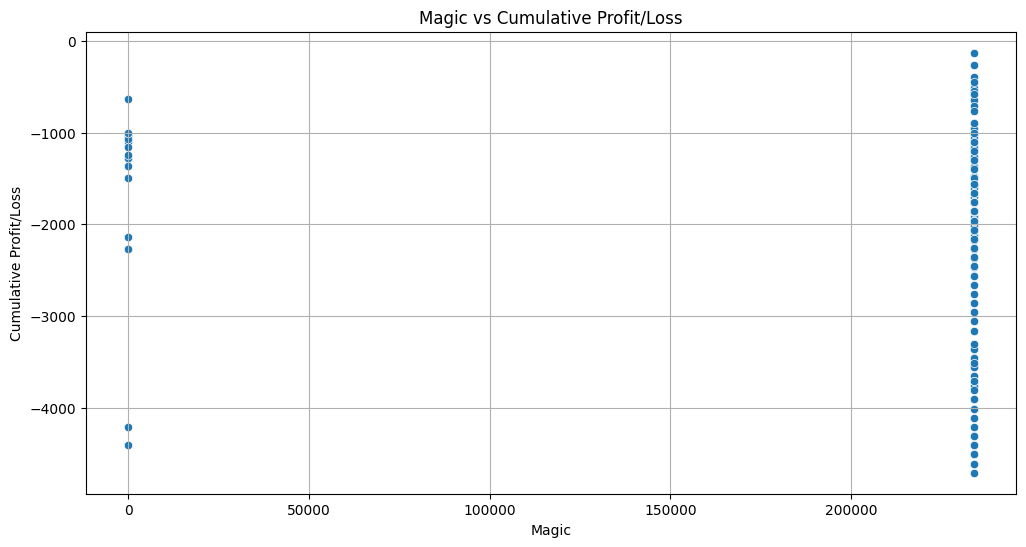

In [63]:
# Scatter plot for Magic vs Cumulative Profit/Loss
plt.figure(figsize=(12, 6))
sns.scatterplot(x='magic', y='Cumulative_Profit_Loss', data=df)
plt.title('Magic vs Cumulative Profit/Loss')
plt.xlabel('Magic')
plt.ylabel('Cumulative Profit/Loss')
plt.grid(True)
plt.show()


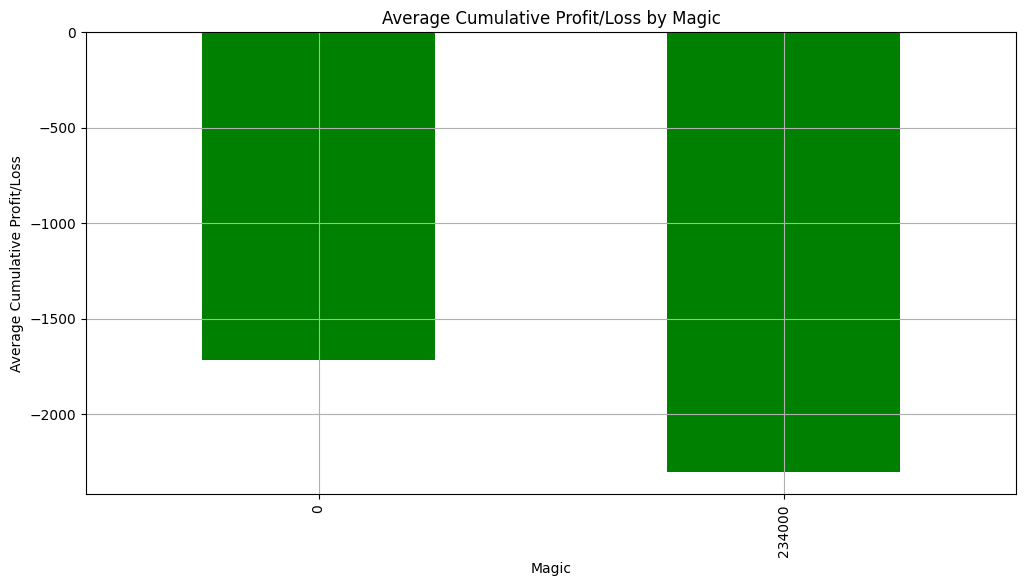

In [64]:
# Grouping by magic and calculating the mean Cumulative Profit/Loss
magic_profit = df.groupby('magic')['Cumulative_Profit_Loss'].mean()

# Plotting the results
plt.figure(figsize=(12, 6))
magic_profit.plot(kind='bar', color='green')
plt.title('Average Cumulative Profit/Loss by Magic')
plt.xlabel('Magic')
plt.ylabel('Average Cumulative Profit/Loss')
plt.grid(True)
plt.show()


In [65]:
import scipy.stats as stats

# Perform ANOVA test (if magic is categorical with multiple categories)
f_stat, p_value = stats.f_oneway(*[df['Cumulative_Profit_Loss'][df['magic'] == magic_value] for magic_value in df['magic'].unique()])
print(f"ANOVA test: F-statistic = {f_stat:.2f}, p-value = {p_value:.2f}")


ANOVA test: F-statistic = 3.34, p-value = 0.07


In [66]:
# Calculating the correlation between magic and Cumulative Profit/Loss
correlation = df['magic'].corr(df['Cumulative_Profit_Loss'])
print(f"Correlation between Magic and Cumulative Profit/Loss: {correlation:.2f}")


Correlation between Magic and Cumulative Profit/Loss: -0.14


In [67]:
total_winning = 2620.56
total_lossing = 3106.65
